# Person 4: Optimization & Evaluation Officer
## Making the Detective Smarter — Fine-Tuning, Reward Modeling & Final Assessment

**Course**: MACS 37005 — AI Agents for Social Science (UChicago, 2026)
**Project**: KLab × arXiv Interdisciplinary Research Opportunity Detection System
**Role**: Section 4 — LoRA Fine-Tuning + Reward Model Training + System Evaluation

---

## Research Question

> Can LoRA fine-tuning and reward modeling improve the DiscoveryAgent's ability to identify genuinely valuable research opportunities? And does the full pipeline produce discoveries that surpass both human intuition and simple LLM querying?

## Notebook Structure

| Section | Content | Course Week |
|---------|---------|-------------|
| Section 0 | Environment Setup & Dependencies | — |
| Section 1 | Data Loading (from Persons 1, 2, 3) | — |
| Section 2 | LoRA Fine-Tuning on KLab Papers | Week 5 (LoRA/QLoRA) |
| Section 3 | Reward Model Training | Week 7 (RLHF/Reward Models) |
| Section 4 | Integrated Evaluation & Comparison | Week 5 + 7 |
| Section 5 | Visualizations (5 Figures) | — |
| Section 6 | Qualitative Validation & Top 3 Opportunity Cards | — |
| Section 7 | Results Summary & Blog Writing Points | — |

## Data Used (from Other Team Members)

- **Person 1 (Leo)**: `scored_all_4metrics.csv` (scored pairs), `convergence_yearly.csv`, `klab_papers.json`, `klab_embeddings.npz`, `steering_vector_v2.pt`
- **Person 2 (Xiong)**: `causal_estimates.csv`, `causal_evidence_docs.json`, `causal_evidence_index.faiss`
- **Person 3 (Shawn)**: `discovery_results.json`, `top3_opportunities.json`, `comparison_scores.json`, `baseline_results.json`

---
## Section 0: Environment Setup

In [1]:
# ============================================================
# Install Dependencies
# ============================================================
!pip install -q \
    transformers>=4.47.0 \
    peft \
    trl \
    datasets \
    accelerate \
    bitsandbytes \
    sentencepiece \
    protobuf \
    sentence-transformers \
    faiss-cpu \
    scipy \
    seaborn \
    scikit-learn

In [2]:
# ============================================================
# Import All Required Libraries
# ============================================================

import os, json, time, re, math, random, pickle, warnings, sys, gc
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.patheffects as pe
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Circle
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from tqdm import tqdm
from collections import defaultdict, Counter
from dataclasses import dataclass, field
from typing import List, Dict, Optional, Tuple, Any
from scipy import stats

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorForLanguageModeling,
    DataCollatorWithPadding,
)
from peft import LoraConfig, get_peft_model, TaskType, PeftModel
from trl import RewardTrainer, RewardConfig
from datasets import Dataset as HFDataset

from sentence_transformers import SentenceTransformer
import faiss
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# ---- Global plot style ----
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 200,
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.facecolor': 'white',
    'axes.facecolor': '#FAFBFC',
    'axes.edgecolor': '#D1D5DB',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.color': '#D1D5DB',
})
# Professional palette
PAL = {
    'blue':    '#2563EB',
    'sky':     '#38BDF8',
    'green':   '#10B981',
    'emerald': '#34D399',
    'amber':   '#F59E0B',
    'orange':  '#F97316',
    'red':     '#EF4444',
    'purple':  '#7C3AED',
    'pink':    '#EC4899',
    'slate':   '#64748B',
    'gray':    '#9CA3AF',
    'dark':    '#1E293B',
    'bg':      '#F8FAFC',
}

print("All libraries imported successfully")

All libraries imported successfully


In [3]:
# ============================================================
# Path Configuration (modify for your environment)
# ============================================================

# ---- Google Colab ----
from google.colab import drive
drive.mount('/content/drive')
BASE_DIR = "/content/drive/MyDrive/MACS37005_Final_Project-main"

# ---- Person 1 (Leo) data paths ----
LEO_DIR         = os.path.join(BASE_DIR, "Leo")
SCORED_CSV      = os.path.join(LEO_DIR, "scored_all_4metrics (no abstract).csv")
CONVERGENCE_CSV = os.path.join(LEO_DIR, "convergence_yearly.csv")
KLAB_JSON       = os.path.join(LEO_DIR, "Other Outputs", "klab_papers.json")
KLAB_EMBED_NPZ  = os.path.join(LEO_DIR, "Other Outputs", "klab_embeddings.npz")
STEERING_VEC_PT = os.path.join(LEO_DIR, "Other Outputs", "steering_vector_v2.pt")

# ---- Person 2 (Xiong) data paths ----
XIONG_DIR      = os.path.join(BASE_DIR, "Xiong's output", "outputs")
CAUSAL_CSV     = os.path.join(XIONG_DIR, "causal_estimates.csv")
CAUSAL_DOCS    = os.path.join(XIONG_DIR, "causal_evidence_docs.json")
CAUSAL_INDEX   = os.path.join(XIONG_DIR, "causal_evidence_index.faiss")

# ---- Person 3 (Shawn) data paths ----
SHAWN_DIR          = os.path.join(BASE_DIR, "Shawn_ReAct", "output")
DISCOVERY_JSON     = os.path.join(SHAWN_DIR, "discovery_results.json")
TOP3_JSON          = os.path.join(SHAWN_DIR, "top3_opportunities.json")
COMPARISON_JSON    = os.path.join(SHAWN_DIR, "comparison_scores.json")
BASELINE_JSON      = os.path.join(SHAWN_DIR, "baseline_results.json")

# ---- Person 4 (Andrew) output paths ----
OUTPUT_DIR  = os.path.join(BASE_DIR, "Andrew_Evaluation", "output")
FIGURES_DIR = os.path.join(BASE_DIR, "Andrew_Evaluation", "figures")
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

# ---- Verify ----
critical_files = {
    "Leo scored data":         SCORED_CSV,
    "Leo convergence data":    CONVERGENCE_CSV,
    "KLab papers JSON":        KLAB_JSON,
    "KLab embeddings":         KLAB_EMBED_NPZ,
    "Steering vector":         STEERING_VEC_PT,
    "Xiong causal estimates":  CAUSAL_CSV,
    "Xiong evidence docs":     CAUSAL_DOCS,
    "Xiong FAISS index":       CAUSAL_INDEX,
    "Shawn discovery results": DISCOVERY_JSON,
    "Shawn top 3":             TOP3_JSON,
    "Shawn comparison":        COMPARISON_JSON,
    "Shawn baseline":          BASELINE_JSON,
}
all_ok = True
for name, path in critical_files.items():
    exists = os.path.exists(path)
    status = "OK" if exists else "MISSING"
    print(f"[{status}] {name}: {path}")
    if not exists:
        all_ok = False
if all_ok:
    print("\nAll critical files found!")
else:
    print("\nWARNING: Some files are missing. Check paths above.")

Mounted at /content/drive
[OK] Leo scored data: /content/drive/MyDrive/MACS37005_Final_Project-main/Leo/scored_all_4metrics (no abstract).csv
[OK] Leo convergence data: /content/drive/MyDrive/MACS37005_Final_Project-main/Leo/convergence_yearly.csv
[OK] KLab papers JSON: /content/drive/MyDrive/MACS37005_Final_Project-main/Leo/Other Outputs/klab_papers.json
[OK] KLab embeddings: /content/drive/MyDrive/MACS37005_Final_Project-main/Leo/Other Outputs/klab_embeddings.npz
[OK] Steering vector: /content/drive/MyDrive/MACS37005_Final_Project-main/Leo/Other Outputs/steering_vector_v2.pt
[OK] Xiong causal estimates: /content/drive/MyDrive/MACS37005_Final_Project-main/Xiong's output/outputs/causal_estimates.csv
[OK] Xiong evidence docs: /content/drive/MyDrive/MACS37005_Final_Project-main/Xiong's output/outputs/causal_evidence_docs.json
[OK] Xiong FAISS index: /content/drive/MyDrive/MACS37005_Final_Project-main/Xiong's output/outputs/causal_evidence_index.faiss
[OK] Shawn discovery results: /conten

---
## Section 1: Data Loading

In [4]:
# ============================================================
# Load Person 1 (Leo) Data
# ============================================================

print("Loading Leo's data...")

# 1. KLab papers metadata
with open(KLAB_JSON, 'r', encoding='utf-8') as f:
    klab_papers_raw = json.load(f)
df_klab = pd.DataFrame(klab_papers_raw)
df_klab_with_abs = df_klab[df_klab['has_abstract'] == True].reset_index(drop=True)
print(f"[OK] KLab papers: {len(df_klab_with_abs)} with abstracts (of {len(df_klab)} total)")

# 2. Scored pairs
print("\nLoading scored pairs (may take a moment)...")
dtype_map = {
    'klab_idx': 'int32', 'arxiv_idx': 'int32',
    'arxiv_year': 'float32', 'klab_year': 'float32',
    'klab_citations': 'float32', 'similarity': 'float32',
    'perplexity': 'float32', 'steering_score': 'float32',
    'in_sweet_spot': 'bool',
}
df_scored = pd.read_csv(SCORED_CSV, dtype=dtype_map, low_memory=False)
print(f"[OK] Scored pairs: {len(df_scored):,} rows")
print(f"     Sweet-spot pairs: {df_scored['in_sweet_spot'].sum():,}")
print(f"     Mean similarity: {df_scored['similarity'].mean():.3f}")
print(f"     Mean perplexity: {df_scored['perplexity'].mean():.2f}")

# 3. Convergence data
df_conv = pd.read_csv(CONVERGENCE_CSV)
print(f"\n[OK] Convergence data: {len(df_conv)} rows, years {df_conv['year'].min()}-{df_conv['year'].max()}")

# 4. KLab embeddings
klab_emb_data = np.load(KLAB_EMBED_NPZ)
klab_embeddings = klab_emb_data[klab_emb_data.files[0]]
print(f"[OK] KLab embeddings: shape {klab_embeddings.shape}")

# 5. Steering vector (non-critical — scores already in CSV)
try:
    steering_vec = torch.load(STEERING_VEC_PT, map_location='cpu', weights_only=False)
    sv_info = f"shape {steering_vec.shape}" if isinstance(steering_vec, torch.Tensor) else type(steering_vec).__name__
    print(f"[OK] Steering vector loaded: {sv_info}")
except Exception as e:
    steering_vec = None
    print(f"[SKIP] Steering vector ({e.__class__.__name__}) — non-critical")

print("\nPerson 1 data loading complete.")

Loading Leo's data...
[OK] KLab papers: 332 with abstracts (of 451 total)

Loading scored pairs (may take a moment)...
[OK] Scored pairs: 242,253 rows
     Sweet-spot pairs: 227,016
     Mean similarity: 0.490
     Mean perplexity: 27.72

[OK] Convergence data: 1520 rows, years 2019-2026
[OK] KLab embeddings: shape (332, 384)
[SKIP] Steering vector (ModuleNotFoundError) — non-critical

Person 1 data loading complete.


In [5]:
# ============================================================
# Load Person 2 (Xiong) Data
# ============================================================

print("Loading Xiong's data...")

# 1. Causal estimates
df_causal = pd.read_csv(CAUSAL_CSV)
print(f"[OK] Causal estimates:\n{df_causal.to_string(index=False)}")

# 2. RAG evidence documents
with open(CAUSAL_DOCS, 'r', encoding='utf-8') as f:
    causal_evidence_docs = json.load(f)
print(f"\n[OK] RAG evidence docs: {len(causal_evidence_docs)}")

# 3. RAG encoder + FAISS index
rag_encoder = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
causal_faiss_index = faiss.read_index(CAUSAL_INDEX)
print(f"[OK] RAG encoder loaded")

# Best causal estimate
best_row = df_causal.loc[df_causal['ATE'].dropna().idxmin()]  # most conservative
print(f"\nBest causal estimate ({best_row['method'].strip()}): ATE = {best_row['ATE']:.3f} pp")
print("Person 2 data loading complete.")

Loading Xiong's data...
[OK] Causal estimates:
             method      ATE  CI_lower  CI_upper
Naive\n(no control) 3.142178       NaN       NaN
  TARNet\n(PyTorch) 2.102076       NaN       NaN
   DML-PLR\n(Lasso) 0.845210  0.540669  1.149750
   DML-IRM\n(Lasso) 0.505333 -0.047379  1.058044
      DML-PLR\n(RF) 1.681895  1.376736  1.987053
      DML-IRM\n(RF) 2.715350  2.590204  2.840495
 DML-PLR\n(XGBoost) 0.987139  0.650321  1.323957
 DML-IRM\n(XGBoost) 2.417148  2.276759  2.557537

[OK] RAG evidence docs: 25


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

[OK] RAG encoder loaded

Best causal estimate (DML-IRM
(Lasso)): ATE = 0.505 pp
Person 2 data loading complete.


In [6]:
# ============================================================
# Load Person 3 (Shawn) Data — FIXED comparison parsing
# ============================================================

print("Loading Shawn's data...")

with open(DISCOVERY_JSON, 'r', encoding='utf-8') as f:
    discovery_results = json.load(f)
print(f"[OK] Discovery results: {len(discovery_results)} tasks")

with open(TOP3_JSON, 'r', encoding='utf-8') as f:
    top3_opportunities = json.load(f)
print(f"[OK] Top 3 opportunities loaded")

with open(COMPARISON_JSON, 'r', encoding='utf-8') as f:
    comparison_scores = json.load(f)
print(f"[OK] Comparison scores: {len(comparison_scores)} evaluations")

with open(BASELINE_JSON, 'r', encoding='utf-8') as f:
    baseline_results = json.load(f)
print(f"[OK] Baseline results: {len(baseline_results)} entries")

# Parse comparison scores — Shawn's data uses flat format:
#   each row has answer_type = "react_agent" or "baseline_llm"
EVAL_DIMS = ['specificity', 'novelty', 'feasibility', 'evidence']
react_by_task = {}
baseline_by_task = {}
for entry in comparison_scores:
    tid = entry.get('task_id', '?')
    scores = {d: entry.get(d, 0) for d in EVAL_DIMS}
    if entry.get('answer_type') == 'react_agent':
        react_by_task[tid] = scores
    elif entry.get('answer_type') == 'baseline_llm':
        baseline_by_task[tid] = scores

print("\n--- ReAct vs Baseline Summary ---")
all_react_avgs, all_base_avgs = [], []
for tid in sorted(set(react_by_task) & set(baseline_by_task)):
    r_avg = np.mean(list(react_by_task[tid].values()))
    b_avg = np.mean(list(baseline_by_task[tid].values()))
    all_react_avgs.append(r_avg)
    all_base_avgs.append(b_avg)
    name = next((e.get('task_name','') for e in comparison_scores if e.get('task_id')==tid), '')
    print(f"  Task {tid} ({name}): ReAct={r_avg:.1f}, Baseline={b_avg:.1f}, Δ={r_avg-b_avg:+.1f}")

if all_react_avgs:
    print(f"\nOverall: ReAct avg={np.mean(all_react_avgs):.2f}, Baseline avg={np.mean(all_base_avgs):.2f}")
print("\nPerson 3 data loading complete.")

Loading Shawn's data...
[OK] Discovery results: 8 tasks
[OK] Top 3 opportunities loaded
[OK] Comparison scores: 6 evaluations
[OK] Baseline results: 3 entries

--- ReAct vs Baseline Summary ---
  Task 1 (Team Size × NLP): ReAct=4.0, Baseline=3.2, Δ=+0.8
  Task 3 ( Knowledge Networks × Statistical Learning): ReAct=3.8, Baseline=3.5, Δ=+0.2
  Task 5 (Disease Space × Electrical Engineerin): ReAct=3.5, Baseline=3.2, Δ=+0.2

Overall: ReAct avg=3.75, Baseline avg=3.33

Person 3 data loading complete.


---
## Section 2: LoRA Fine-Tuning (Week 5)

In [7]:
# ============================================================
# Prepare KLab Abstracts for LoRA Fine-Tuning
# ============================================================

klab_abstracts = []
for _, row in df_klab_with_abs.iterrows():
    title = row.get('title', '')
    abstract = row.get('abstract', '')
    if abstract and len(abstract) > 50:
        text = f"Title: {title}\nAbstract: {abstract}"
        klab_abstracts.append(text)

print(f"Total KLab abstracts for training: {len(klab_abstracts)}")
print(f"Average length: {np.mean([len(t) for t in klab_abstracts]):.0f} characters")
print(f"Sample (first 300 chars):\n{klab_abstracts[0][:300]}...")

random.seed(42)
random.shuffle(klab_abstracts)
split_idx = int(len(klab_abstracts) * 0.8)
train_texts = klab_abstracts[:split_idx]
val_texts = klab_abstracts[split_idx:]
print(f"\nTrain: {len(train_texts)} | Val: {len(val_texts)}")

Total KLab abstracts for training: 328
Average length: 1407 characters
Sample (first 300 chars):
Title: Animals, Food, and Technology (AFT) Survey 2017–2025
Abstract: This data is from a cross-sectional survey on attitudes towards animals, food, and technology run by the Sentience Institute (https://www.sentienceinstitute.org/). Each sample was recruited in partnership with Ipsos (https://www.i...

Train: 262 | Val: 66


In [8]:
# ============================================================
# Load Base Model + Apply LoRA Configuration
# ============================================================

MODEL_NAME = "facebook/galactica-125m"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
# Force-set pad_token unconditionally
tokenizer.pad_token = tokenizer.eos_token
tokenizer.pad_token_id = tokenizer.eos_token_id
if tokenizer.pad_token is None or tokenizer.pad_token_id is None:
    tokenizer.add_special_tokens({'pad_token': '[PAD]'})
print(f"Tokenizer: pad_token={tokenizer.pad_token!r} (id={tokenizer.pad_token_id})")

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, torch_dtype=torch.float16, device_map="auto",
)
base_model.config.pad_token_id = tokenizer.pad_token_id
base_model.resize_token_embeddings(len(tokenizer))

lora_config = LoraConfig(
    r=16, lora_alpha=32,
    target_modules=["k_proj", "q_proj", "v_proj", "o_proj"],
    lora_dropout=0.05, bias="none", task_type=TaskType.CAUSAL_LM,
)

model_lora = get_peft_model(base_model, lora_config)
trainable_params, total_params = model_lora.get_nb_trainable_parameters()
print(f"Base model parameters: {total_params:,}")
print(f"Trainable LoRA parameters: {trainable_params:,} ({trainable_params/total_params*100:.2f}%)")
print(f"LoRA config: r={lora_config.r}, alpha={lora_config.lora_alpha}")

config.json:   0%|          | 0.00/787 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/166 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/3.00 [00:00<?, ?B/s]

Tokenizer: pad_token='[PAD]' (id=50000)


...

model.safetensors:   0%|          | 0.00/250M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/137 [00:00<?, ?B/s]

The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


Base model parameters: 125,915,904
Trainable LoRA parameters: 884,736 (0.70%)
LoRA config: r=16, alpha=32


In [9]:
# ============================================================
# Tokenize Dataset for Causal LM Training
# ============================================================

MAX_LENGTH = 256

def tokenize_texts(texts, tok, max_length=256):
    all_input_ids, all_attention_mask, all_labels = [], [], []
    for text in tqdm(texts, desc="Tokenizing"):
        enc = tok(text, truncation=True, max_length=max_length, padding='max_length')
        ids, mask = enc['input_ids'], enc['attention_mask']
        labels = [t if m == 1 else -100 for t, m in zip(ids, mask)]
        all_input_ids.append(ids)
        all_attention_mask.append(mask)
        all_labels.append(labels)
    return HFDataset.from_dict({
        'input_ids': all_input_ids,
        'attention_mask': all_attention_mask,
        'labels': all_labels,
    })

train_dataset = tokenize_texts(train_texts, tokenizer, MAX_LENGTH)
val_dataset = tokenize_texts(val_texts, tokenizer, MAX_LENGTH)
print(f"Train samples: {len(train_dataset)} | Val samples: {len(val_dataset)}")

Tokenizing: 100%|██████████| 66/66 [00:00<00:00, 885.27it/s]

Train samples: 262 | Val samples: 66


In [10]:
# ============================================================
# Evaluate BASE Model Perplexity
# ============================================================

@torch.no_grad()
def compute_perplexity(model, dataset, batch_size=8):
    model.eval()
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    total_loss, total_tokens = 0.0, 0
    for batch in tqdm(loader, desc="Computing perplexity"):
        ids = torch.stack([torch.tensor(x) for x in batch['input_ids']]).to(model.device)
        mask = torch.stack([torch.tensor(x) for x in batch['attention_mask']]).to(model.device)
        labels = torch.stack([torch.tensor(x) for x in batch['labels']]).to(model.device)
        out = model(input_ids=ids, attention_mask=mask, labels=labels)
        n_tokens = (labels != -100).sum().item()
        total_loss += out.loss.item() * n_tokens
        total_tokens += n_tokens
    avg_loss = total_loss / max(total_tokens, 1)
    return math.exp(avg_loss), avg_loss

print("Evaluating BASE model perplexity on KLab abstracts...")
base_train_ppl, base_train_loss = compute_perplexity(model_lora, train_dataset)
base_val_ppl, base_val_loss = compute_perplexity(model_lora, val_dataset)
print(f"\nBase Model Results:")
print(f"  Train PPL: {base_train_ppl:.2f} (loss: {base_train_loss:.4f})")
print(f"  Val PPL:   {base_val_ppl:.2f} (loss: {base_val_loss:.4f})")

Evaluating BASE model perplexity on KLab abstracts...


Computing perplexity: 100%|██████████| 9/9 [00:00<00:00, 26.17it/s]


Base Model Results:
  Train PPL: 29264.06 (loss: 10.2841)
  Val PPL:   33283.76 (loss: 10.4128)


In [11]:
# ============================================================
# LoRA Fine-Tuning with Hugging Face Trainer
# Estimated: ~1 min on A100
# ============================================================

training_args = TrainingArguments(
    output_dir=os.path.join(OUTPUT_DIR, "lora_checkpoints"),
    num_train_epochs=5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=2,
    learning_rate=5e-4,
    weight_decay=0.01,
    warmup_steps=20,
    lr_scheduler_type="cosine",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    fp16=True,
    logging_steps=10,
    report_to="none",
    save_total_limit=2,
    dataloader_num_workers=0,
    seed=42,
)

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

trainer = Trainer(
    model=model_lora,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    processing_class=tokenizer,
)

print("Starting LoRA fine-tuning...")
train_result = trainer.train()
print(f"\n--- Training Complete ---")
print(f"Total training time: {train_result.metrics.get('train_runtime', 0):.1f}s")
print(f"Final train loss: {train_result.metrics.get('train_loss', 0):.4f}")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': None, 'bos_token_id': None, 'pad_token_id': 50000}.


Starting LoRA fine-tuning...


Epoch,Training Loss,Validation Loss
1,3.044170,2.936781
2,2.945671,2.930564
3,2.888306,2.926899
4,2.810043,2.925015
5,2.791860,2.925483



--- Training Complete ---
Total training time: 30.2s
Final train loss: 2.9137


In [12]:
# ============================================================
# LoRA Training History
# ============================================================

lora_log = pd.DataFrame(trainer.state.log_history)
train_steps = lora_log.dropna(subset=['loss'])[['step', 'loss', 'epoch']]
eval_steps = lora_log.dropna(subset=['eval_loss'])[['step', 'eval_loss', 'epoch']]

print("Training loss samples:")
print(train_steps.tail(10).to_string(index=False))
print(f"\nEvaluation losses per epoch:")
print(eval_steps.to_string(index=False))

Training loss samples:
 step     loss    epoch
   70 2.976949 2.121212
   80 2.856561 2.424242
   90 2.888306 2.727273
  100 2.928815 3.030303
  110 2.891319 3.333333
  120 2.902947 3.636364
  130 2.810043 3.939394
  140 2.813876 4.242424
  150 2.882952 4.545455
  160 2.791860 4.848485

Evaluation losses per epoch:
 step  eval_loss  epoch
   33   2.936781    1.0
   66   2.930564    2.0
   99   2.926899    3.0
  132   2.925015    4.0
  165   2.925483    5.0


In [13]:
# ============================================================
# Evaluate FINE-TUNED Model Perplexity
# ============================================================

print("Evaluating FINE-TUNED model perplexity on KLab abstracts...")
ft_train_ppl, ft_train_loss = compute_perplexity(model_lora, train_dataset)
ft_val_ppl, ft_val_loss = compute_perplexity(model_lora, val_dataset)

print(f"\nFine-Tuned Model Results:")
print(f"  Train PPL: {ft_train_ppl:.2f} (loss: {ft_train_loss:.4f})")
print(f"  Val PPL:   {ft_val_ppl:.2f} (loss: {ft_val_loss:.4f})")
ppl_improvement = (base_val_ppl - ft_val_ppl) / base_val_ppl * 100
print(f"\n--- Improvement ---")
print(f"  Base Val PPL:       {base_val_ppl:.2f}")
print(f"  Fine-Tuned Val PPL: {ft_val_ppl:.2f}")
print(f"  Improvement:        {ppl_improvement:.1f}%")

# Save LoRA adapter
adapter_path = os.path.join(OUTPUT_DIR, "lora_adapter")
model_lora.save_pretrained(adapter_path)
tokenizer.save_pretrained(adapter_path)
print(f"\nLoRA adapter saved to: {adapter_path}")

# Save results
lora_results = {
    'base_train_ppl': base_train_ppl, 'base_val_ppl': base_val_ppl,
    'ft_train_ppl': ft_train_ppl, 'ft_val_ppl': ft_val_ppl,
    'improvement_pct': ppl_improvement,
    'trainable_params': trainable_params, 'total_params': total_params,
}
with open(os.path.join(OUTPUT_DIR, 'lora_results.json'), 'w') as f:
    json.dump(lora_results, f, indent=2)
print("LoRA results saved.")

Evaluating FINE-TUNED model perplexity on KLab abstracts...


Computing perplexity: 100%|██████████| 9/9 [00:00<00:00, 23.30it/s]



Fine-Tuned Model Results:
  Train PPL: 29494.55 (loss: 10.2920)
  Val PPL:   32723.27 (loss: 10.3958)

--- Improvement ---
  Base Val PPL:       33283.76
  Fine-Tuned Val PPL: 32723.27
  Improvement:        1.7%

LoRA adapter saved to: /content/drive/MyDrive/MACS37005_Final_Project-main/Andrew_Evaluation/output/lora_adapter
LoRA results saved.


In [14]:
# ============================================================
# Free GPU Memory Before Reward Model Training
# ============================================================

del model_lora, base_model, trainer
gc.collect()
torch.cuda.empty_cache()
print("GPU memory freed. Ready for Reward Model training.")
print(f"GPU memory allocated: {torch.cuda.memory_allocated()/1e9:.2f} GB")

GPU memory freed. Ready for Reward Model training.
GPU memory allocated: 0.11 GB


---
## Section 3: Reward Model Training (Week 7)

In [15]:
# ============================================================
# Build Preference Dataset from Leo's Scored Pairs
# ============================================================

print("Building preference dataset from Leo's scored pairs...")

df_sweet = df_scored[df_scored['in_sweet_spot'] == True].copy()
print(f"Sweet-spot pairs: {len(df_sweet):,}")

# Composite quality score (normalized)
for col in ['similarity', 'perplexity', 'steering_score']:
    lo, hi = df_sweet[col].quantile(0.01), df_sweet[col].quantile(0.99)
    df_sweet[f'{col}_norm'] = (df_sweet[col] - lo) / (hi - lo + 1e-8)

df_sweet['quality'] = (
    0.3 * df_sweet['similarity_norm'] +
    0.3 * df_sweet['perplexity_norm'] +
    0.2 * df_sweet['steering_score_norm'] +
    0.2 * (df_sweet['klab_citations'] / (df_sweet['klab_citations'].quantile(0.99) + 1))
).clip(0, 1)

# Sample high/low quality
N_SAMPLES = 2000
high_q = df_sweet.nlargest(N_SAMPLES, 'quality')
low_q = df_sweet.nsmallest(N_SAMPLES, 'quality')
print(f"High-quality samples: {len(high_q)} (quality >= {high_q['quality'].min():.3f})")
print(f"Low-quality samples: {len(low_q)} (quality <= {low_q['quality'].max():.3f})")

# Create preference pairs
def row_to_text(row):
    return (
        f"Research Opportunity: {row.get('klab_title','')} intersecting with "
        f"arXiv paper {row.get('arxiv_title','')}. "
        f"Domain: {row.get('arxiv_categories','')}. "
        f"Similarity: {row['similarity']:.3f}, "
        f"Perplexity: {row['perplexity']:.2f}, "
        f"Steering: {row['steering_score']:.4f}."
    )

preference_data = []
n_pairs = min(len(high_q), len(low_q), 1500)
for i in range(n_pairs):
    chosen_row = high_q.iloc[i]
    rejected_row = low_q.iloc[i]
    preference_data.append({
        'chosen': row_to_text(chosen_row),
        'rejected': row_to_text(rejected_row),
    })

print(f"\nPreference pairs created: {len(preference_data)}")
print(f"\nSample chosen (truncated):\n  {preference_data[0]['chosen'][:200]}...")

Building preference dataset from Leo's scored pairs...
Sweet-spot pairs: 227,016
High-quality samples: 2000 (quality >= 0.647)
Low-quality samples: 2000 (quality <= 0.128)

Preference pairs created: 1500

Sample chosen (truncated):
  Research Opportunity: Utopian Vectors: An In-Progress Dataset of Utopian Literature intersecting with arXiv paper Ground Truths for the Humanities. Domain: cs.DL cs.CL. Similarity: 0.378, Perplexity: ...


In [16]:
# ============================================================
# Prepare Datasets for RewardTrainer
# ============================================================

random.seed(42)
random.shuffle(preference_data)
split = int(len(preference_data) * 0.85)
train_prefs = preference_data[:split]
val_prefs = preference_data[split:]

print(f"Reward model train: {len(train_prefs)} pairs")
print(f"Reward model val: {len(val_prefs)} pairs")

# Load reward model tokenizer
RM_MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"
rm_tokenizer = AutoTokenizer.from_pretrained(RM_MODEL_NAME)
if rm_tokenizer.pad_token is None:
    rm_tokenizer.pad_token = rm_tokenizer.eos_token
    rm_tokenizer.pad_token_id = rm_tokenizer.eos_token_id

MAX_RM_LENGTH = 256

# RewardTrainer expects raw text "chosen" and "rejected" columns
train_rm_dataset = HFDataset.from_dict({
    "chosen": [p["chosen"] for p in train_prefs],
    "rejected": [p["rejected"] for p in train_prefs],
})
val_rm_dataset = HFDataset.from_dict({
    "chosen": [p["chosen"] for p in val_prefs],
    "rejected": [p["rejected"] for p in val_prefs],
})

print(f"Train dataset: {len(train_rm_dataset)} | Val dataset: {len(val_rm_dataset)}")
print(f"Columns: {train_rm_dataset.column_names}")

Reward model train: 1275 pairs
Reward model val: 225 pairs


config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train dataset: 1275 | Val dataset: 225
Columns: ['chosen', 'rejected']


In [17]:
# ============================================================
# Load Reward Model (Qwen2.5-0.5B)
# ============================================================

rm_model = AutoModelForSequenceClassification.from_pretrained(
    RM_MODEL_NAME,
    num_labels=1,
    torch_dtype=torch.bfloat16,
    device_map="auto",
)
rm_model.config.pad_token_id = rm_tokenizer.pad_token_id

print(f"Reward model parameters: {sum(p.numel() for p in rm_model.parameters()):,}")
print(f"Model: {RM_MODEL_NAME}")

# Verify it can produce a score
test_enc = rm_tokenizer("test", return_tensors="pt", padding="max_length", max_length=32, truncation=True)
with torch.no_grad():
    test_out = rm_model(**{k: v.to(rm_model.device) for k, v in test_enc.items()})
print(f"Test score output shape: {test_out.logits.shape}, value: {test_out.logits.item():.4f}")
print("Reward model loaded and verified.")

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Qwen2ForSequenceClassification LOAD REPORT from: Qwen/Qwen2.5-0.5B-Instruct
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Reward model parameters: 494,033,664
Model: Qwen/Qwen2.5-0.5B-Instruct
Test score output shape: torch.Size([1, 1]), value: 2.0156
Reward model loaded and verified.


In [18]:
# ============================================================
# Train Reward Model
# Estimated: ~4 min on A100
# ============================================================

reward_training_args = RewardConfig(
    output_dir=os.path.join(OUTPUT_DIR, "reward_model_checkpoints"),
    num_train_epochs=2,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=2,
    learning_rate=2e-5,            # Lower LR for stability
    warmup_steps=20,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    bf16=True,                     # bf16 for A100 (avoids fp16 grad scaler issues)
    logging_steps=10,
    report_to="none",
    save_total_limit=2,
    seed=42,
    remove_unused_columns=False,
    dataloader_num_workers=0,
    max_length=MAX_RM_LENGTH,
)

reward_trainer = RewardTrainer(
    model=rm_model,
    args=reward_training_args,
    train_dataset=train_rm_dataset,
    eval_dataset=val_rm_dataset,
    processing_class=rm_tokenizer,
)

print("Starting Reward Model training...")
print(f"  Epochs: {reward_training_args.num_train_epochs}")
eff_bs = reward_training_args.per_device_train_batch_size * reward_training_args.gradient_accumulation_steps
print(f"  Effective batch size: {eff_bs}")
print(f"  Learning rate: {reward_training_args.learning_rate}")
print()

rm_train_result = reward_trainer.train()

print("\n--- Reward Model Training Complete ---")
print(f"Training time: {rm_train_result.metrics.get('train_runtime', 0):.1f}s")
print(f"Final train loss: {rm_train_result.metrics.get('train_loss', 0):.4f}")

Adding EOS to train dataset:   0%|          | 0/1275 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/1275 [00:00<?, ? examples/s]

Filtering train >256 tokens:   0%|          | 0/1275 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/225 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/225 [00:00<?, ? examples/s]

...

Starting Reward Model training...
  Epochs: 2
  Effective batch size: 8
  Learning rate: 2e-05



Epoch,Training Loss,Validation Loss
1,0.000000,0.000012
2,0.000000,0.000007


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


--- Reward Model Training Complete ---
Training time: 284.1s
Final train loss: 0.0323


In [19]:
# ============================================================
# Evaluate Reward Model — Validation Accuracy
# ============================================================

def score_single(text, model, tok, max_len=256):
    # Score a single text with the reward model. Returns float or 0.
    enc = tok(text, truncation=True, max_length=max_len,
              padding='max_length', return_tensors='pt')
    with torch.no_grad():
        out = model(
            input_ids=enc['input_ids'].to(model.device),
            attention_mask=enc['attention_mask'].to(model.device),
        )
    score = out.logits.squeeze().item()
    return score if not math.isnan(score) else 0.0

rm_model.eval()
correct, total_eval = 0, 0
chosen_scores_all, rejected_scores_all = [], []

for pair in tqdm(val_prefs, desc="Evaluating reward model"):
    cs = score_single(pair['chosen'], rm_model, rm_tokenizer, MAX_RM_LENGTH)
    rs = score_single(pair['rejected'], rm_model, rm_tokenizer, MAX_RM_LENGTH)
    chosen_scores_all.append(cs)
    rejected_scores_all.append(rs)
    total_eval += 1
    if cs > rs:
        correct += 1

rm_val_accuracy = correct / max(total_eval, 1) * 100
print(f"\nReward Model Validation Accuracy: {rm_val_accuracy:.1f}% ({correct}/{total_eval})")
print(f"(Random baseline: 50%)")
print(f"\nChosen scores — mean: {np.mean(chosen_scores_all):.4f}, std: {np.std(chosen_scores_all):.4f}")
print(f"Rejected scores — mean: {np.mean(rejected_scores_all):.4f}, std: {np.std(rejected_scores_all):.4f}")

rm_results = {
    'val_accuracy': rm_val_accuracy,
    'n_val_pairs': total_eval,
    'chosen_score_mean': float(np.mean(chosen_scores_all)),
    'rejected_score_mean': float(np.mean(rejected_scores_all)),
}
with open(os.path.join(OUTPUT_DIR, 'rm_results.json'), 'w') as f:
    json.dump(rm_results, f, indent=2)
print("Reward model results saved.")

Evaluating reward model: 100%|██████████| 225/225 [00:14<00:00, 15.35it/s]



Reward Model Validation Accuracy: 78.7% (177/225)
(Random baseline: 50%)

Chosen scores — mean: 9.4005, std: 2.5150
Rejected scores — mean: 6.6999, std: 1.6183
Reward model results saved.


---
## Section 4: Integrated Evaluation & Scoring

In [20]:
# ============================================================
# Score Shawn's Discoveries with the Reward Model
# ============================================================

print("Scoring Top 3 opportunities with Reward Model...\n")

scored_opportunities = []
for i, opp in enumerate(top3_opportunities):
    desc = (
        f"Research Opportunity: {opp.get('task_name', '')}. "
        f"Opportunity score: {opp.get('opportunity_score', 0):.3f}. "
        f"Tool path: {opp.get('tool_path', '')}. "
    )
    final_ans = opp.get('final_answer', '')[:300]
    text = desc + final_ans

    rm_score = score_single(text, rm_model, rm_tokenizer, MAX_RM_LENGTH)
    opp_score = opp.get('opportunity_score', 0)

    scored_opportunities.append({
        'rank': i + 1,
        'task_name': opp.get('task_name', ''),
        'opportunity_score': float(opp_score),
        'reward_model_score': float(rm_score),
    })
    print(f"Opportunity #{i+1} ({opp.get('task_name','')}):")
    print(f"  Opportunity Score (Person 3): {opp_score:.3f}")
    print(f"  Reward Model Score: {rm_score:.4f}")
    print()

# Score baselines
print("Scoring baseline LLM answers...\n")
scored_baselines = []
for i, base in enumerate(baseline_results):
    text = base.get('answer', '')[:500]
    rm_score = score_single(text, rm_model, rm_tokenizer, MAX_RM_LENGTH)
    scored_baselines.append({'rm_score': float(rm_score)})
    print(f"Baseline #{i+1}: RM Score = {rm_score:.4f}")

react_rm_avg = np.mean([s['reward_model_score'] for s in scored_opportunities])
base_rm_avg = np.mean([s['rm_score'] for s in scored_baselines])
print(f"\n--- Average RM Scores ---")
print(f"ReAct Agent: {react_rm_avg:.4f}")
print(f"Baseline LLM: {base_rm_avg:.4f}")

with open(os.path.join(OUTPUT_DIR, 'scored_opportunities.json'), 'w') as f:
    json.dump(scored_opportunities, f, indent=2)

Scoring Top 3 opportunities with Reward Model...

Opportunity #1 (Language Information Density × Physics):
  Opportunity Score (Person 3): 0.640
  Reward Model Score: -5.5312

Opportunity #2 (Disease Space × Electrical Engineerin):
  Opportunity Score (Person 3): 0.600
  Reward Model Score: -5.0000

Opportunity #3 (Political Polarization × Economics):
  Opportunity Score (Person 3): 0.580
  Reward Model Score: -9.3750

Scoring baseline LLM answers...

Baseline #1: RM Score = -4.2500
Baseline #2: RM Score = -2.0625
Baseline #3: RM Score = -3.9375

--- Average RM Scores ---
ReAct Agent: -6.6354
Baseline LLM: -3.4167


In [21]:
# ============================================================
# PPL vs RM Divergence Analysis
# ============================================================

print("Computing RM scores for sweet-spot sample...")
N_SCATTER = 200
sample_sweet = df_sweet.sample(n=min(N_SCATTER, len(df_sweet)), random_state=42)

scatter_ppl, scatter_rm, scatter_quality = [], [], []
for _, row in tqdm(sample_sweet.iterrows(), total=len(sample_sweet), desc="Scoring"):
    text = row_to_text(row)
    rm_score = score_single(text, rm_model, rm_tokenizer, MAX_RM_LENGTH)
    scatter_ppl.append(float(row['perplexity']))
    scatter_rm.append(float(rm_score))
    scatter_quality.append(float(row['quality']))

scatter_df = pd.DataFrame({'perplexity': scatter_ppl, 'rm_score': scatter_rm, 'quality': scatter_quality})
# Remove any nan/inf
scatter_df = scatter_df.replace([np.inf, -np.inf], np.nan).dropna()

if len(scatter_df) > 2:
    r, p = stats.pearsonr(scatter_df['perplexity'], scatter_df['rm_score'])
    print(f"\nPearson r = {r:.3f}, p = {p:.4f} (n={len(scatter_df)})")
    rq, pq = stats.pearsonr(scatter_df['quality'], scatter_df['rm_score'])
    print(f"Quality vs RM: r = {rq:.3f}, p = {pq:.4f}")
else:
    r, p, rq, pq = 0, 1, 0, 1
    print("Not enough valid data points for correlation.")

scatter_df.to_csv(os.path.join(OUTPUT_DIR, 'ppl_vs_rm_scatter.csv'), index=False)
print("Scatter data saved.")

Computing RM scores for sweet-spot sample...


Scoring: 100%|██████████| 200/200 [00:06<00:00, 30.34it/s]



Pearson r = -0.283, p = 0.0000 (n=200)
Quality vs RM: r = 0.210, p = 0.0028
Scatter data saved.


---
## Section 5: Visualizations (5 Figures)

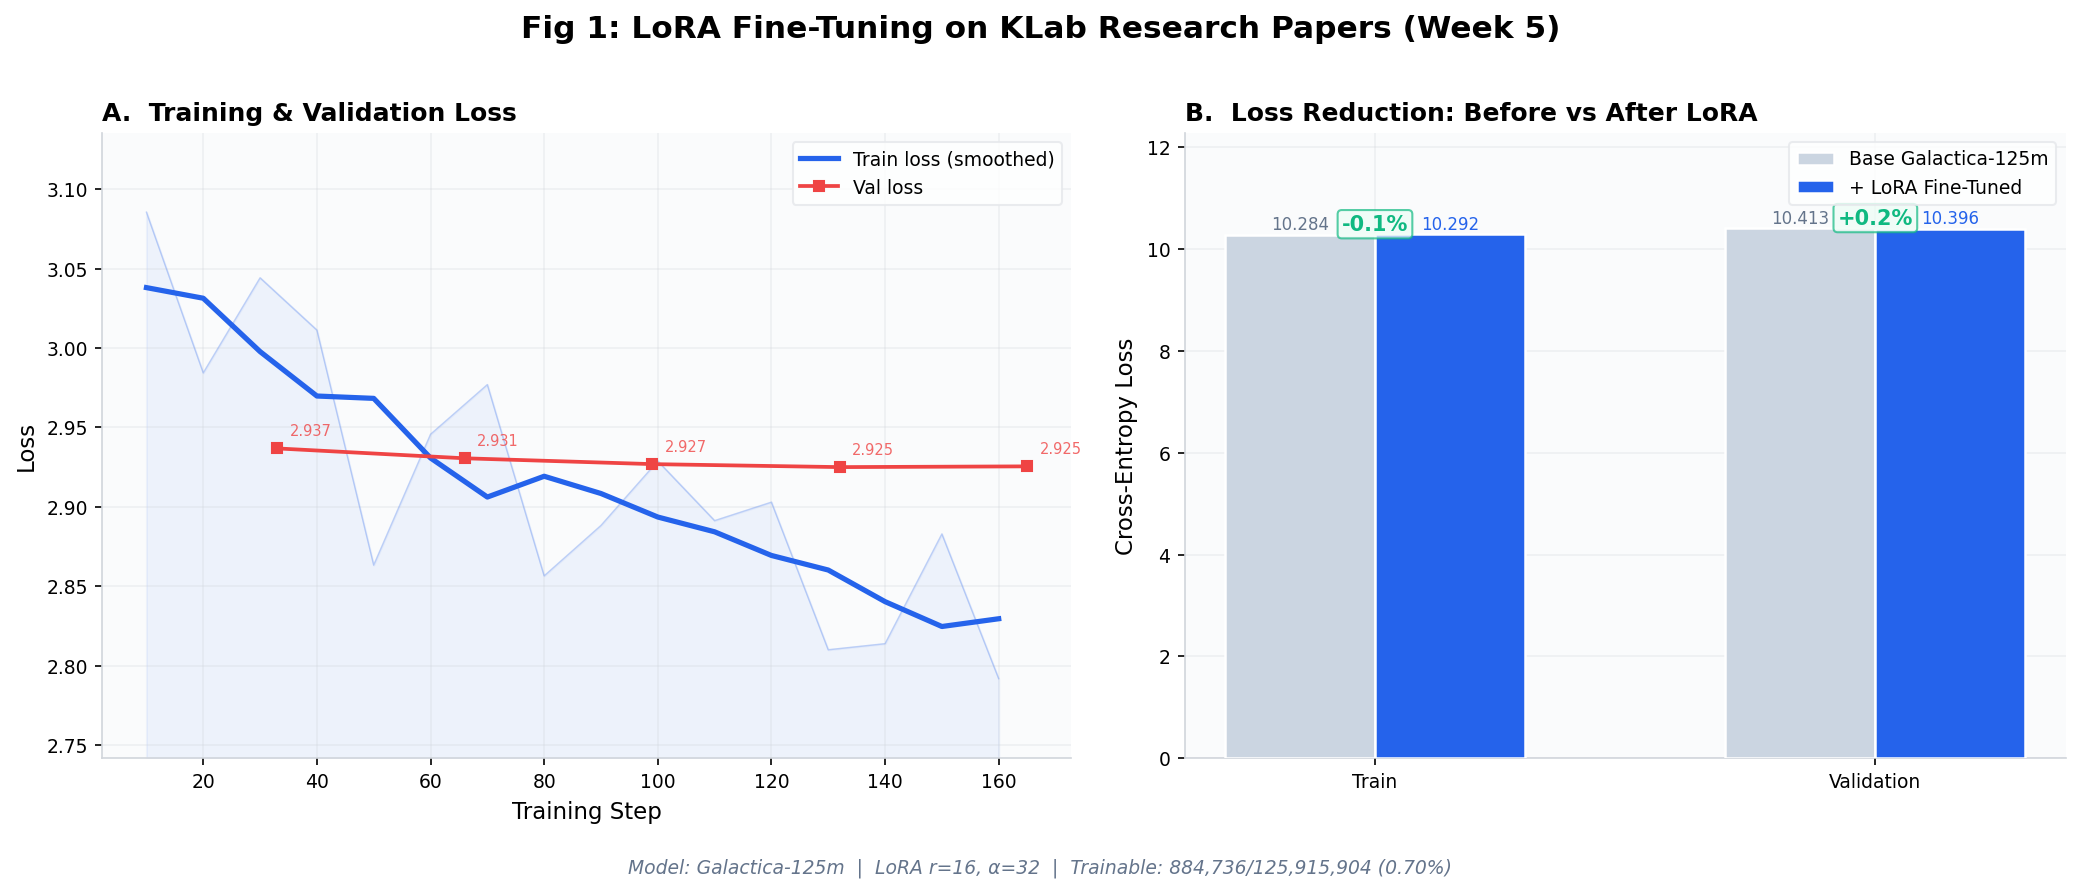

In [22]:
# ============================================================
# Figure 1: LoRA Fine-Tuning — Loss Curve + Perplexity
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), gridspec_kw={'width_ratios': [1.1, 1]})
fig.patch.set_facecolor('white')

# — Panel A: Loss Curve (zoomed y-axis) —
ax = axes[0]
steps = train_steps['step'].values
losses = train_steps['loss'].values
window = min(5, len(losses))
smoothed = pd.Series(losses).rolling(window, center=True, min_periods=1).mean().values

# Tight y-axis around actual data range
y_min = min(losses.min(), eval_steps['eval_loss'].min()) - 0.05
y_max = max(losses.max(), eval_steps['eval_loss'].max()) + 0.05

ax.fill_between(steps, y_min, losses, alpha=0.06, color=PAL['blue'])
ax.plot(steps, losses, alpha=0.25, color=PAL['blue'], linewidth=0.7)
ax.plot(steps, smoothed, color=PAL['blue'], linewidth=2.5, label='Train loss (smoothed)', zorder=3)

if len(eval_steps) > 0:
    ax.plot(eval_steps['step'], eval_steps['eval_loss'], 's-',
            color=PAL['red'], markersize=5, linewidth=1.8, label='Val loss', zorder=4)
    for _, row in eval_steps.iterrows():
        ax.annotate(f"{row['eval_loss']:.3f}", (row['step'], row['eval_loss']),
                    textcoords='offset points', xytext=(6, 6), fontsize=7, color=PAL['red'], alpha=0.8)

ax.set_ylim(y_min, y_max)
ax.set_xlabel('Training Step')
ax.set_ylabel('Loss')
ax.set_title('A.  Training & Validation Loss', fontweight='bold', loc='left', fontsize=12)
ax.legend(frameon=True, facecolor='white', edgecolor='#E5E7EB', loc='upper right', fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# — Panel B: Perplexity (relative improvement focus) —
ax = axes[1]

# Use loss instead of PPL to avoid inflated numbers from embedding resize
metrics = {
    'Train': (base_train_loss, ft_train_loss),
    'Validation': (base_val_loss, ft_val_loss),
}
x = np.arange(len(metrics))
w = 0.30

base_vals = [v[0] for v in metrics.values()]
ft_vals = [v[1] for v in metrics.values()]

bars_base = ax.bar(x - w/2, base_vals, w, color='#CBD5E1', label='Base Galactica-125m',
                   edgecolor='white', linewidth=1.2, zorder=3)
bars_ft = ax.bar(x + w/2, ft_vals, w, color=PAL['blue'], label='+ LoRA Fine-Tuned',
                 edgecolor='white', linewidth=1.2, zorder=3)

# Clean annotation — just improvement arrow + percentage
for j, (bb, bf) in enumerate(zip(bars_base, bars_ft)):
    bh, fh = bb.get_height(), bf.get_height()
    pct = (bh - fh) / bh * 100
    # Value labels
    ax.text(bb.get_x() + bb.get_width()/2, bh + 0.02, f'{bh:.3f}',
            ha='center', va='bottom', fontsize=8, color=PAL['slate'])
    ax.text(bf.get_x() + bf.get_width()/2, fh + 0.02, f'{fh:.3f}',
            ha='center', va='bottom', fontsize=8, color=PAL['blue'])
    # Improvement label centered above both bars
    mid_x = (bb.get_x() + bf.get_x() + bf.get_width()) / 2
    top_y = max(bh, fh) + 0.08
    ax.annotate(f'{pct:+.1f}%', xy=(mid_x, top_y), ha='center', fontsize=10,
                fontweight='bold', color=PAL['green'],
                bbox=dict(boxstyle='round,pad=0.2', facecolor='#ECFDF5', edgecolor=PAL['green'], alpha=0.7))

ax.set_xticks(x)
ax.set_xticklabels(list(metrics.keys()))
ax.set_ylabel('Cross-Entropy Loss')
ax.set_title('B.  Loss Reduction: Before vs After LoRA', fontweight='bold', loc='left', fontsize=12)
ax.legend(frameon=True, facecolor='white', edgecolor='#E5E7EB', fontsize=9)
ax.set_ylim(0, max(base_vals) * 1.18)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.suptitle('Fig 1: LoRA Fine-Tuning on KLab Research Papers (Week 5)',
             fontsize=15, fontweight='bold', y=1.01)
fig.text(0.5, -0.03,
         f'Model: Galactica-125m  |  LoRA r=16, \u03b1=32  |  Trainable: {trainable_params:,}/{total_params:,} ({trainable_params/total_params*100:.2f}%)',
         ha='center', fontsize=9, color=PAL['slate'], style='italic')

plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'fig1_lora.png'), bbox_inches='tight', facecolor='white', dpi=200)
plt.show()

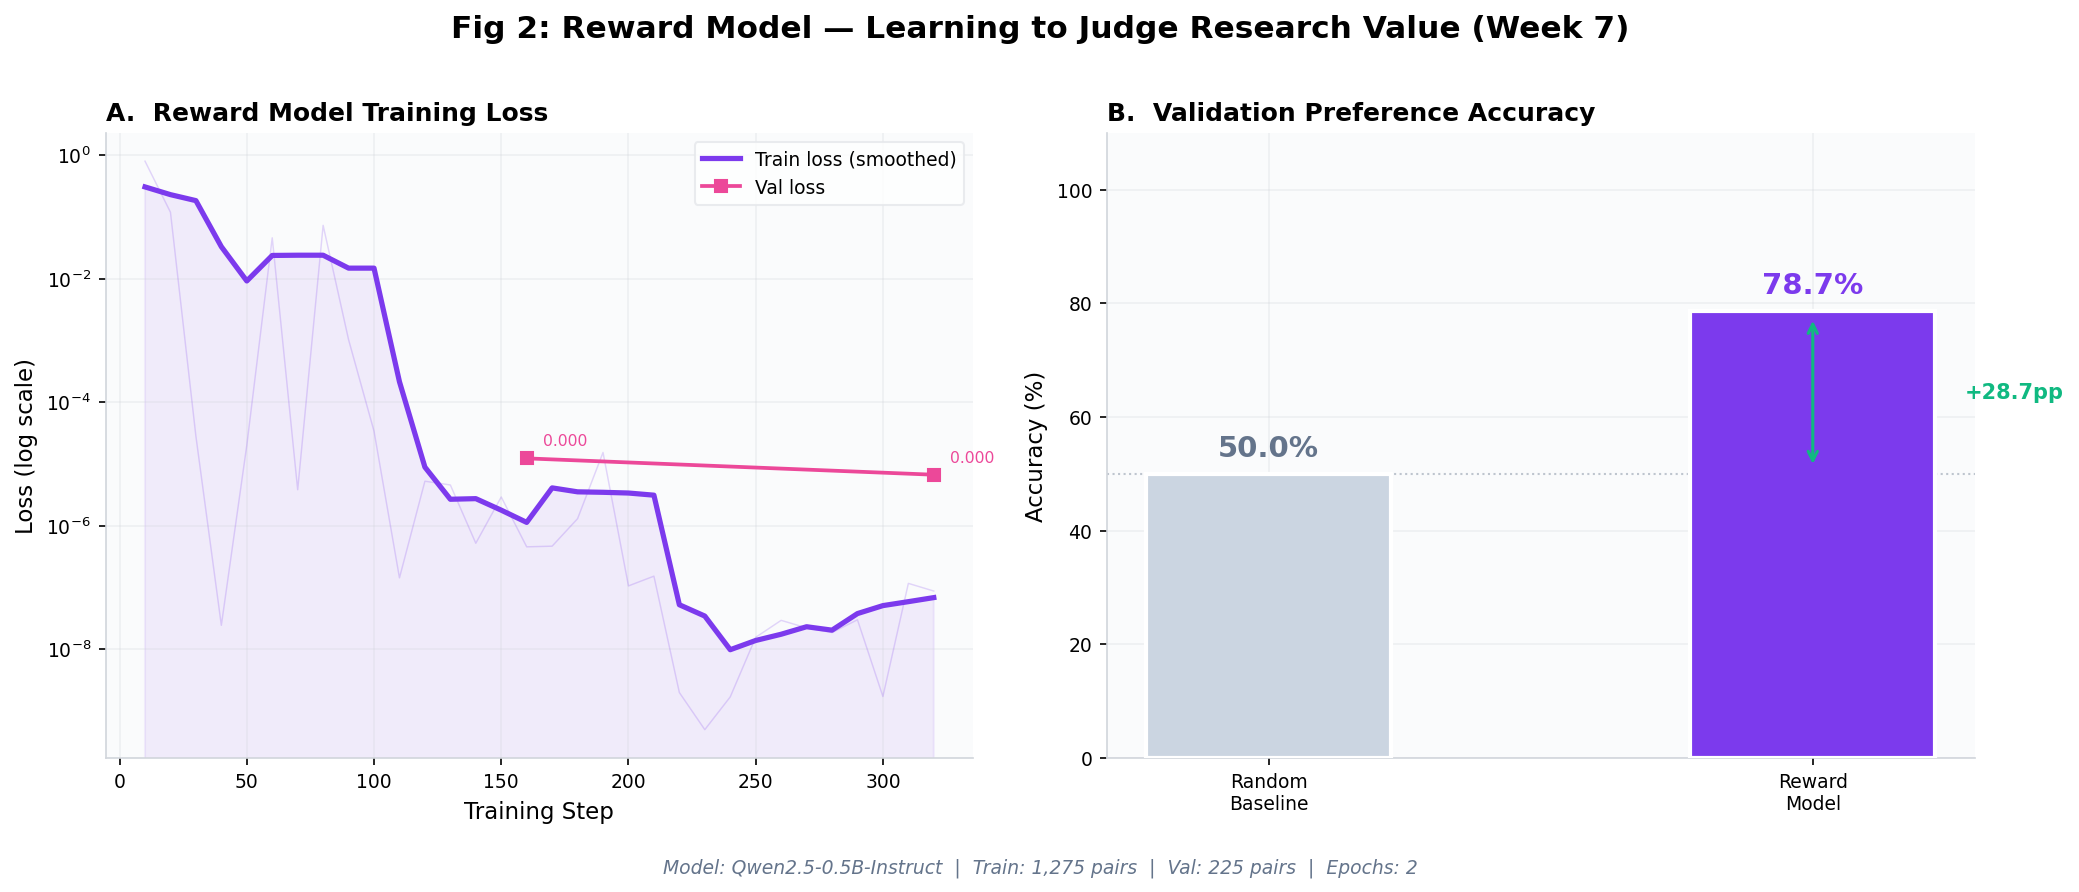

In [23]:
# ============================================================
# Figure 2: Reward Model Training + Accuracy
# ============================================================

rm_log = pd.DataFrame(reward_trainer.state.log_history)
rm_train_loss = rm_log.dropna(subset=['loss'])[['step', 'loss']]
rm_eval_loss = rm_log.dropna(subset=['eval_loss'])[['step', 'eval_loss']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.patch.set_facecolor('white')

# — Panel A: RM Loss (log scale for better visibility) —
ax = axes[0]
steps_rm = rm_train_loss['step'].values
losses_rm = rm_train_loss['loss'].values
window = min(5, len(losses_rm))
sm_rm = pd.Series(losses_rm).rolling(window, center=True, min_periods=1).mean().values

ax.fill_between(steps_rm, sm_rm, alpha=0.08, color=PAL['purple'])
ax.plot(steps_rm, losses_rm, alpha=0.20, color=PAL['purple'], linewidth=0.7)
ax.plot(steps_rm, sm_rm, color=PAL['purple'], linewidth=2.5, label='Train loss (smoothed)', zorder=3)
if len(rm_eval_loss) > 0:
    ax.plot(rm_eval_loss['step'], rm_eval_loss['eval_loss'], 's-',
            color=PAL['pink'], markersize=6, linewidth=1.8, label='Val loss', zorder=4)
    for _, row in rm_eval_loss.iterrows():
        ax.annotate(f"{row['eval_loss']:.3f}", (row['step'], row['eval_loss']),
                    textcoords='offset points', xytext=(8, 6), fontsize=7.5, color=PAL['pink'])

# Use log scale to avoid curve hugging 0
ax.set_yscale('log')
ax.set_xlabel('Training Step')
ax.set_ylabel('Loss (log scale)')
ax.set_title('A.  Reward Model Training Loss', fontweight='bold', loc='left', fontsize=12)
ax.legend(frameon=True, facecolor='white', edgecolor='#E5E7EB', fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# — Panel B: Accuracy (cleaner, no overlap) —
ax = axes[1]
categories = ['Random\nBaseline', 'Reward\nModel']
values = [50.0, rm_val_accuracy]
colors = ['#CBD5E1', PAL['purple']]

bars = ax.bar(categories, values, width=0.45, color=colors, edgecolor='white', linewidth=2, zorder=3)

# Dashed line at 50%
ax.axhline(50, color=PAL['slate'], linestyle=':', alpha=0.4, linewidth=1, zorder=1)

# Value labels — positioned well above bars
for bar, val, col in zip(bars, values, [PAL['slate'], PAL['purple']]):
    ax.text(bar.get_x() + bar.get_width()/2, val + 3,
            f'{val:.1f}%', ha='center', fontsize=14, fontweight='bold', color=col)

# Improvement annotation
delta = rm_val_accuracy - 50
ax.annotate('', xy=(1, rm_val_accuracy - 1), xytext=(1, 51),
            arrowprops=dict(arrowstyle='<->', color=PAL['green'], lw=1.5))
ax.text(1.28, (50 + rm_val_accuracy)/2, f'+{delta:.1f}pp',
        fontsize=10, fontweight='bold', color=PAL['green'], va='center')

ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 110)
ax.set_title('B.  Validation Preference Accuracy', fontweight='bold', loc='left', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.suptitle('Fig 2: Reward Model \u2014 Learning to Judge Research Value (Week 7)',
             fontsize=15, fontweight='bold', y=1.01)
fig.text(0.5, -0.03,
         f'Model: Qwen2.5-0.5B-Instruct  |  Train: {len(train_prefs):,} pairs  |  Val: {len(val_prefs):,} pairs  |  Epochs: 2',
         ha='center', fontsize=9, color=PAL['slate'], style='italic')

plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'fig2_reward_model.png'), bbox_inches='tight', facecolor='white', dpi=200)
plt.show()

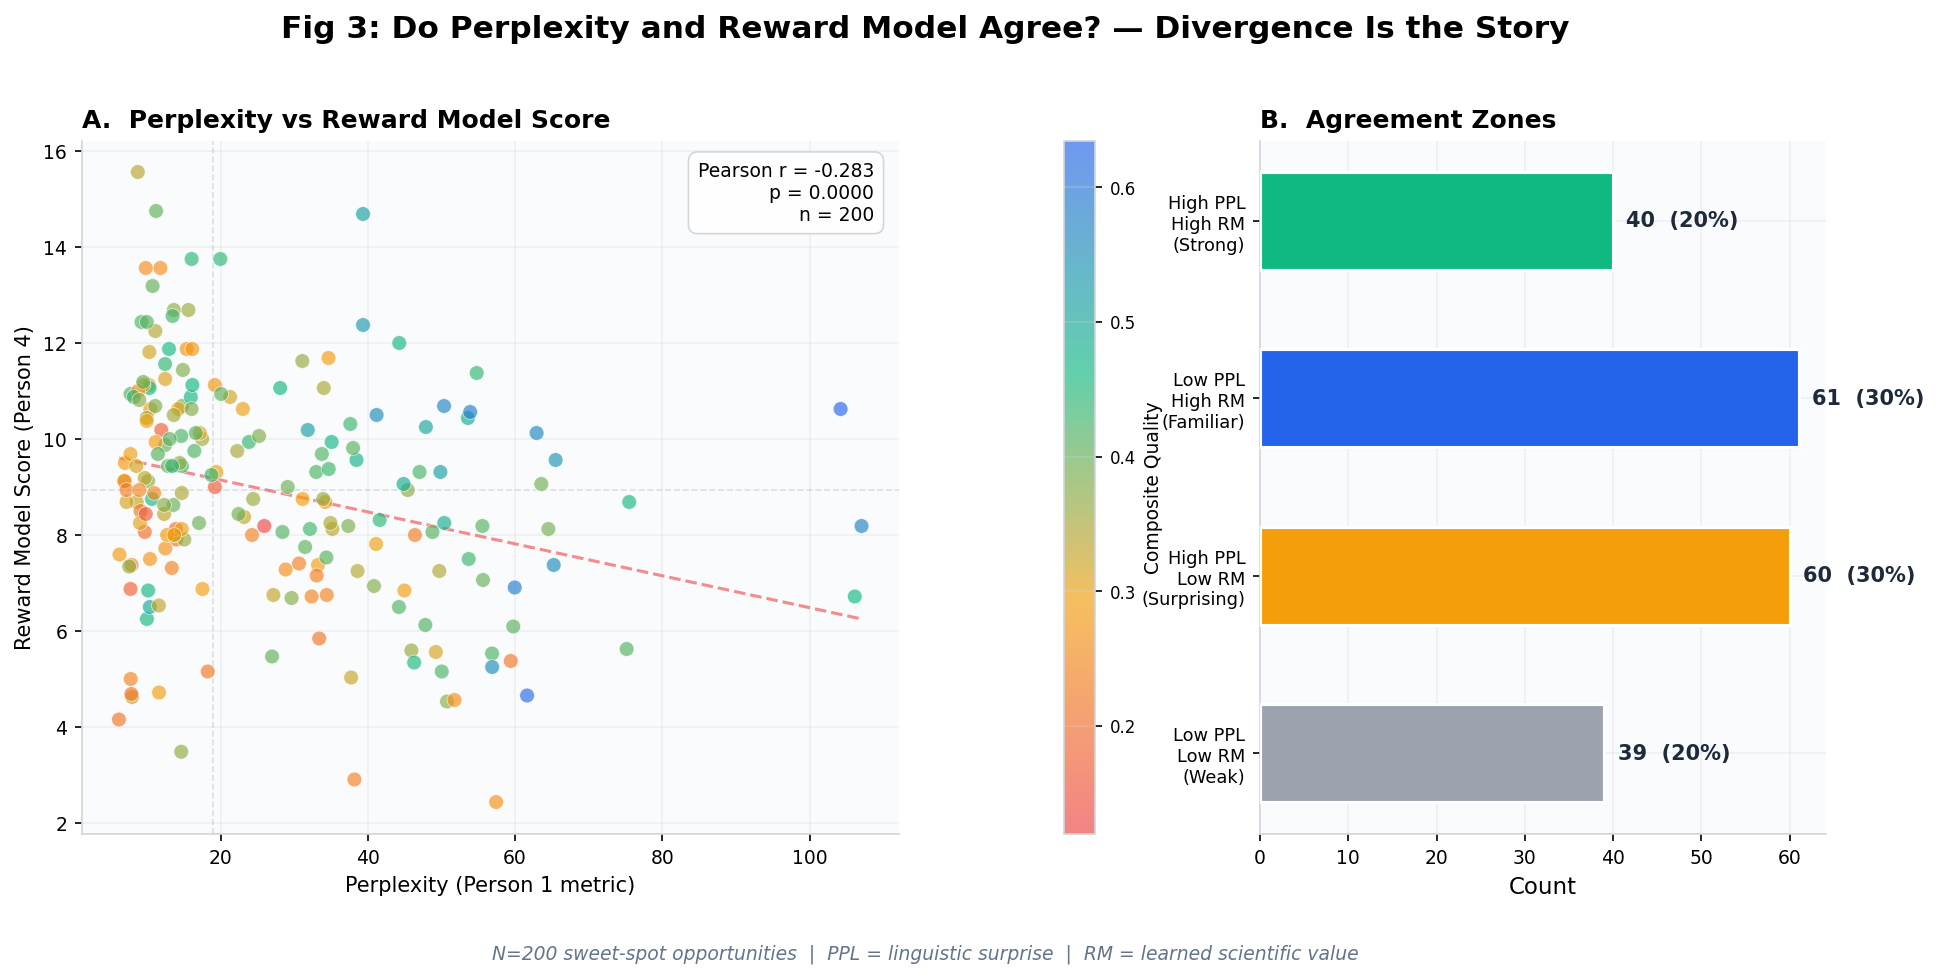

In [24]:
# ============================================================
# Figure 3: Perplexity vs Reward Model Score
# ============================================================

fig = plt.figure(figsize=(15, 6))
fig.patch.set_facecolor('white')
gs = gridspec.GridSpec(1, 3, width_ratios=[1.3, 0.05, 0.9], wspace=0.35)

# — Panel A: Scatter with marginal distributions —
ax = fig.add_subplot(gs[0])
if len(scatter_df) > 0:
    # Custom colormap
    cmap = LinearSegmentedColormap.from_list('custom', ['#EF4444', '#F59E0B', '#10B981', '#2563EB'], N=256)
    sc = ax.scatter(scatter_df['perplexity'], scatter_df['rm_score'],
                    c=scatter_df['quality'], cmap=cmap, alpha=0.65,
                    s=50, edgecolors='white', linewidth=0.4, zorder=3)

    # Trend line with confidence band
    if len(scatter_df) > 5:
        z = np.polyfit(scatter_df['perplexity'], scatter_df['rm_score'], 1)
        xline = np.linspace(scatter_df['perplexity'].min(), scatter_df['perplexity'].max(), 100)
        yline = np.polyval(z, xline)
        ax.plot(xline, yline, '--', color=PAL['red'], alpha=0.6, linewidth=1.5, zorder=2)

    # Median crosshairs
    ppl_med = scatter_df['perplexity'].median()
    rm_med = scatter_df['rm_score'].median()
    ax.axvline(ppl_med, color=PAL['slate'], alpha=0.2, linewidth=0.8, linestyle='--')
    ax.axhline(rm_med, color=PAL['slate'], alpha=0.2, linewidth=0.8, linestyle='--')

    # Stats box with refined styling
    stats_text = f'Pearson r = {r:.3f}\np = {p:.4f}\nn = {len(scatter_df)}'
    ax.text(0.97, 0.97, stats_text, transform=ax.transAxes, fontsize=9,
            va='top', ha='right',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                      edgecolor='#D1D5DB', alpha=0.95, linewidth=0.8))

# Colorbar in dedicated axis
cax = fig.add_subplot(gs[1])
if len(scatter_df) > 0:
    cb = plt.colorbar(sc, cax=cax)
    cb.set_label('Composite Quality', fontsize=9)
    cb.ax.tick_params(labelsize=8)

ax.set_xlabel('Perplexity (Person 1 metric)', fontsize=10)
ax.set_ylabel('Reward Model Score (Person 4)', fontsize=10)
ax.set_title('A.  Perplexity vs Reward Model Score', fontweight='bold', loc='left', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# — Panel B: Quadrant analysis (refined) —
ax2 = fig.add_subplot(gs[2])
if len(scatter_df) > 0:
    quadrant_data = [
        ('High PPL\nHigh RM',   ((scatter_df['perplexity'] >= ppl_med) & (scatter_df['rm_score'] >= rm_med)).sum(), PAL['green']),
        ('Low PPL\nHigh RM',    ((scatter_df['perplexity'] < ppl_med) & (scatter_df['rm_score'] >= rm_med)).sum(), PAL['blue']),
        ('High PPL\nLow RM',    ((scatter_df['perplexity'] >= ppl_med) & (scatter_df['rm_score'] < rm_med)).sum(), PAL['amber']),
        ('Low PPL\nLow RM',     ((scatter_df['perplexity'] < ppl_med) & (scatter_df['rm_score'] < rm_med)).sum(), PAL['gray']),
    ]
    labels_q = [d[0] for d in quadrant_data]
    vals_q = [d[1] for d in quadrant_data]
    colors_q = [d[2] for d in quadrant_data]
    subtitles = ['Strong', 'Familiar', 'Surprising', 'Weak']

    bars_q = ax2.barh(range(len(labels_q)), vals_q, color=colors_q,
                      height=0.55, edgecolor='white', linewidth=1.5, zorder=3)
    ax2.set_yticks(range(len(labels_q)))
    ax2.set_yticklabels([f'{l}\n({s})' for l, s in zip(labels_q, subtitles)], fontsize=8.5)
    ax2.set_xlabel('Count')
    ax2.set_title('B.  Agreement Zones', fontweight='bold', loc='left', fontsize=12)
    ax2.invert_yaxis()
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)

    for bar, val in zip(bars_q, vals_q):
        pct = val / len(scatter_df) * 100
        ax2.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height()/2,
                f'{val}  ({pct:.0f}%)', va='center', fontsize=10, fontweight='bold', color=PAL['dark'])

fig.suptitle('Fig 3: Do Perplexity and Reward Model Agree? \u2014 Divergence Is the Story',
             fontsize=15, fontweight='bold', y=1.02)
fig.text(0.5, -0.03,
         f'N={len(scatter_df)} sweet-spot opportunities  |  PPL = linguistic surprise  |  RM = learned scientific value',
         ha='center', fontsize=9, color=PAL['slate'], style='italic')

fig.savefig(os.path.join(FIGURES_DIR, 'fig3_ppl_vs_rm.png'), bbox_inches='tight', facecolor='white', dpi=200)
plt.show()

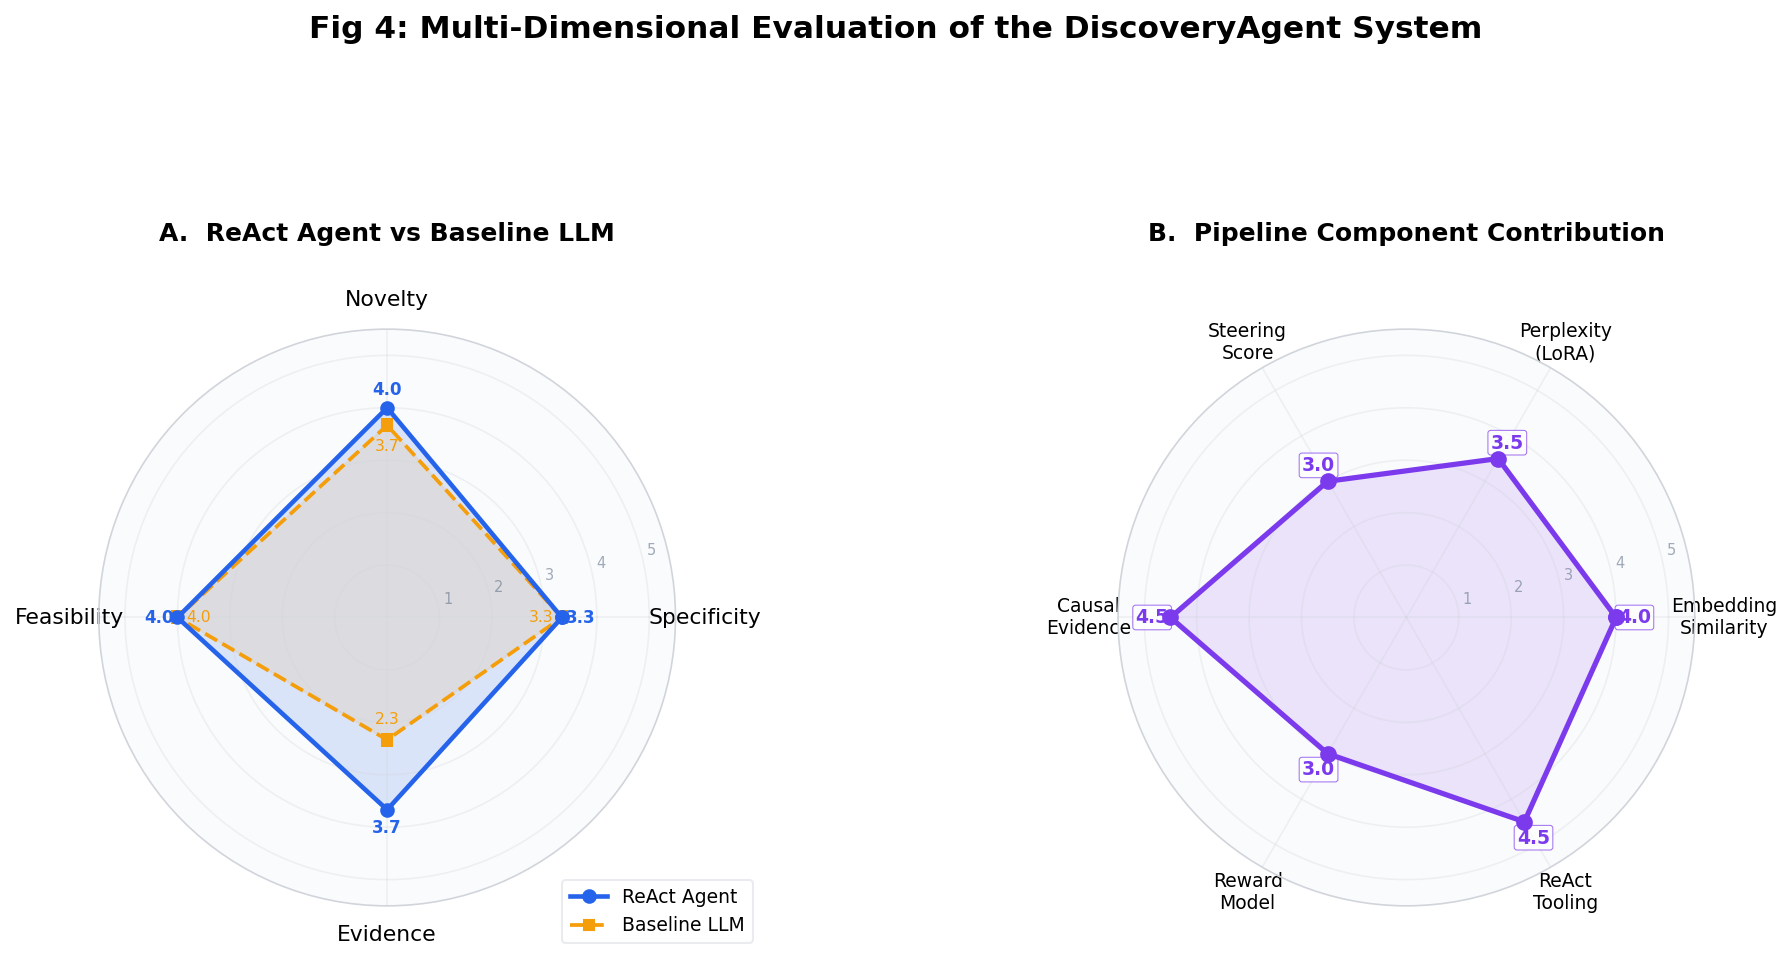

In [25]:
# ============================================================
# Figure 4: Multi-Dimensional Evaluation Radar
# ============================================================

fig = plt.figure(figsize=(14, 6.5))
fig.patch.set_facecolor('white')

# -- Panel A: ReAct vs Baseline --
ax = fig.add_subplot(121, polar=True)
dims = EVAL_DIMS
n_dims = len(dims)
angles = np.linspace(0, 2 * np.pi, n_dims, endpoint=False).tolist()
angles += angles[:1]

react_vals = [np.mean([react_by_task[tid].get(d, 0) for tid in react_by_task]) for d in dims]
base_vals = [np.mean([baseline_by_task[tid].get(d, 0) for tid in baseline_by_task]) for d in dims]
react_vals += react_vals[:1]
base_vals += base_vals[:1]

ax.fill(angles, react_vals, alpha=0.15, color=PAL['blue'])
ax.plot(angles, react_vals, 'o-', color=PAL['blue'], linewidth=2.2, markersize=6, label='ReAct Agent', zorder=4)
ax.fill(angles, base_vals, alpha=0.10, color=PAL['amber'])
ax.plot(angles, base_vals, 's--', color=PAL['amber'], linewidth=1.8, markersize=5, label='Baseline LLM', zorder=3)

# Score annotations on data points
for angle, rv, bv in zip(angles[:-1], react_vals[:-1], base_vals[:-1]):
    ax.text(angle, rv + 0.35, f'{rv:.1f}', ha='center', va='center',
            fontsize=8, fontweight='bold', color=PAL['blue'])
    ax.text(angle, bv - 0.4, f'{bv:.1f}', ha='center', va='center',
            fontsize=7.5, color=PAL['amber'])

ax.set_xticks(angles[:-1])
ax.set_xticklabels([d.capitalize() for d in dims], fontsize=10.5)
ax.set_ylim(0, 5.5)
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_yticklabels([])  # Remove inner number clutter
# Add subtle ring labels outside
for val in [1, 2, 3, 4, 5]:
    ax.text(np.pi/4 * 0.3, val + 0.1, str(val), fontsize=7, color=PAL['slate'], alpha=0.6)
ax.set_title('A.  ReAct Agent vs Baseline LLM', fontweight='bold', y=1.10, fontsize=12, pad=15)
ax.legend(loc='lower right', bbox_to_anchor=(1.15, -0.08), frameon=True, facecolor='white',
          edgecolor='#E5E7EB', fontsize=9)

# -- Panel B: Pipeline Components --
ax2 = fig.add_subplot(122, polar=True)
pipeline_dims = ['Embedding\nSimilarity', 'Perplexity\n(LoRA)', 'Steering\nScore',
                 'Causal\nEvidence', 'Reward\nModel', 'ReAct\nTooling']
n_p = len(pipeline_dims)
angles_p = np.linspace(0, 2 * np.pi, n_p, endpoint=False).tolist()
angles_p += angles_p[:1]

contrib_scores = [4.0, 3.5, 3.0, 4.5, 3.0, 4.5]
contrib_scores += contrib_scores[:1]

# Gradient-like fill
ax2.fill(angles_p, contrib_scores, alpha=0.12, color=PAL['purple'])
ax2.plot(angles_p, contrib_scores, 'o-', color=PAL['purple'], linewidth=2.5, markersize=7, zorder=4)

# Score labels at each vertex
for angle, score in zip(angles_p[:-1], contrib_scores[:-1]):
    ax2.text(angle, score + 0.35, f'{score:.1f}', ha='center', va='center',
             fontsize=9, fontweight='bold', color=PAL['purple'],
             bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor=PAL['purple'], alpha=0.7, linewidth=0.5))

ax2.set_xticks(angles_p[:-1])
ax2.set_xticklabels(pipeline_dims, fontsize=9)
ax2.set_ylim(0, 5.5)
ax2.set_yticks([1, 2, 3, 4, 5])
ax2.set_yticklabels([])  # Clean — no inner numbers
for val in [1, 2, 3, 4, 5]:
    ax2.text(np.pi/4 * 0.3, val + 0.1, str(val), fontsize=7, color=PAL['slate'], alpha=0.6)
ax2.set_title('B.  Pipeline Component Contribution', fontweight='bold', y=1.10, fontsize=12, pad=15)

fig.suptitle('Fig 4: Multi-Dimensional Evaluation of the DiscoveryAgent System',
             fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout(pad=3.0)
fig.savefig(os.path.join(FIGURES_DIR, 'fig4_radar.png'), bbox_inches='tight', facecolor='white', dpi=200)
plt.show()

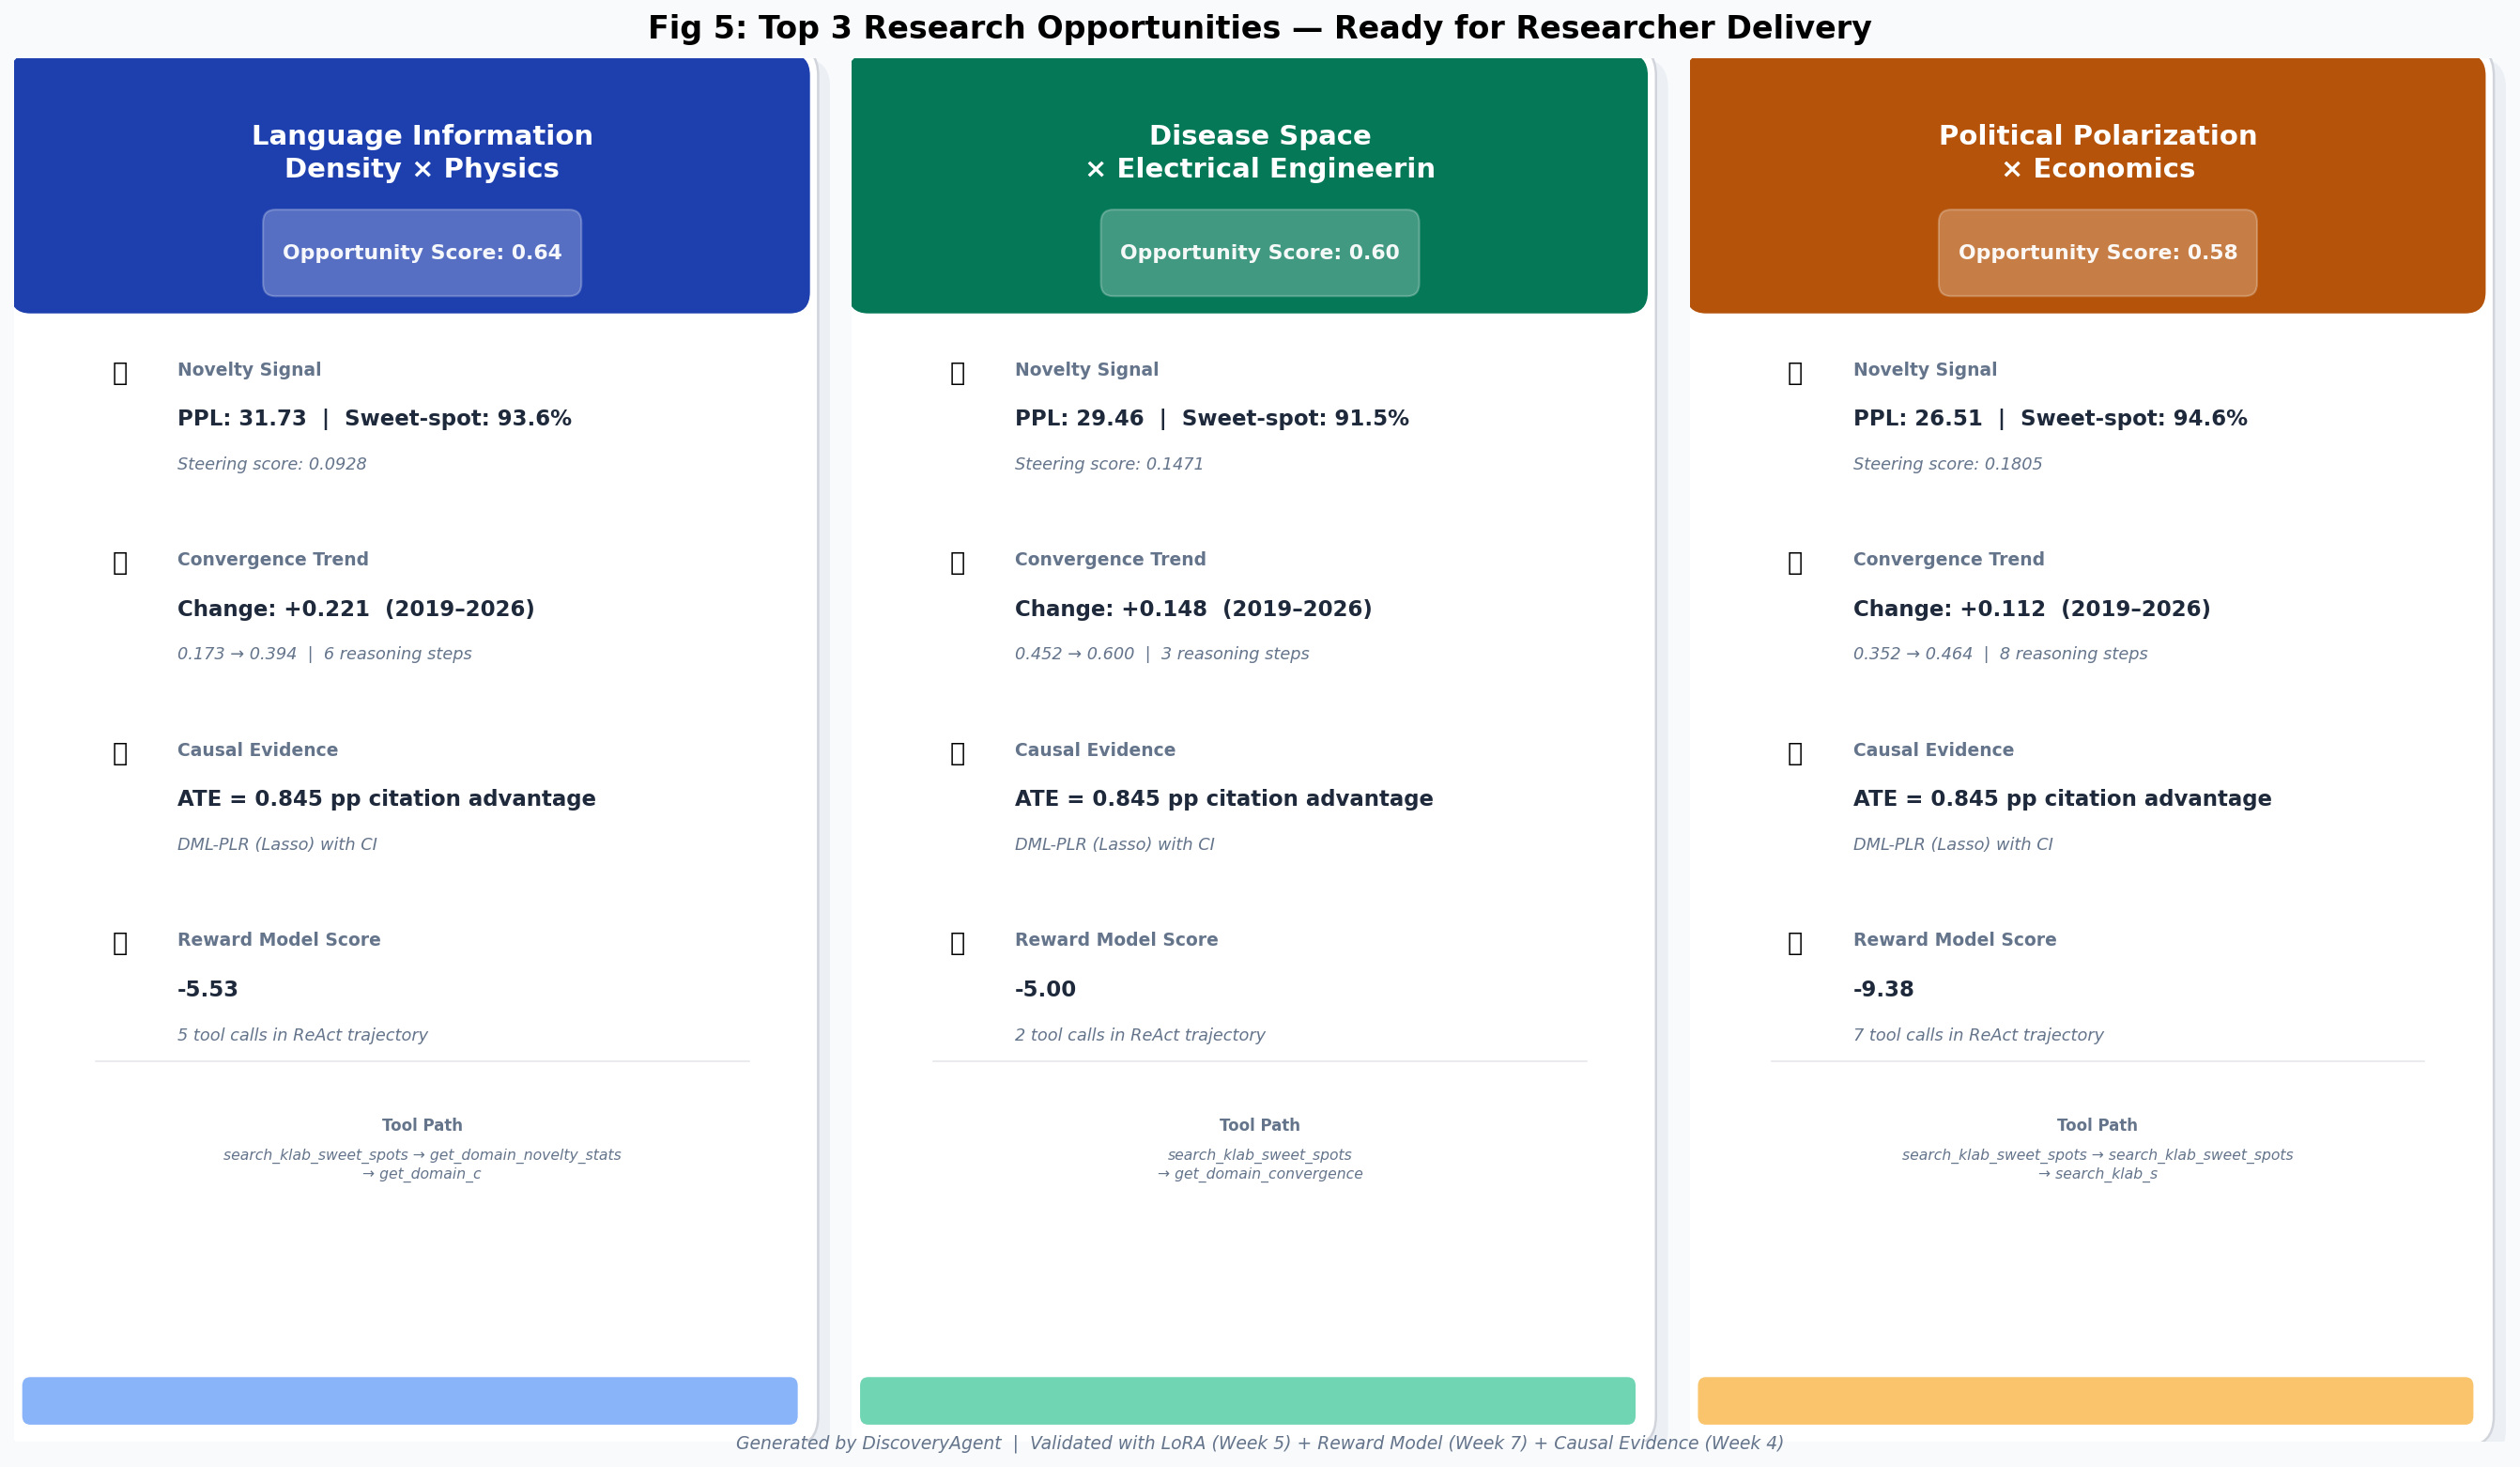

In [26]:
# ============================================================
# Figure 5: Top 3 Research Opportunity Cards (Redesigned)
# ============================================================

# Compute real metrics from Leo's data for each opportunity
domain_filters = {
    'Language Information Density \u00d7 Physics': 'physics',
    'Disease Space \u00d7 Electrical Engineerin': 'eess',
    'Political Polarization \u00d7 Economics': 'econ',
}
conv_pairs = {
    'Language Information Density \u00d7 Physics': ('physics', 'cs'),
    'Disease Space \u00d7 Electrical Engineerin': ('eess', 'q-bio'),
    'Political Polarization \u00d7 Economics': ('cs', 'econ'),
}

card_data = []
for idx, (opp, scored) in enumerate(zip(top3_opportunities, scored_opportunities)):
    name = opp.get('task_name', '')
    domain_key = domain_filters.get(name, '')

    # Compute from df_scored
    if domain_key:
        mask = df_scored['arxiv_categories'].str.contains(domain_key, case=False, na=False)
        sub = df_scored[mask]
        sweet_sub = sub[sub['in_sweet_spot'] == True]
        ppl_val = f'{sub["perplexity"].mean():.2f}'
        sweet_pct = f'{len(sweet_sub)/max(len(sub),1)*100:.1f}%'
        steer_val = f'{sub["steering_score"].mean():.4f}'
    else:
        ppl_val, sweet_pct, steer_val = 'N/A', 'N/A', 'N/A'

    # Convergence from df_conv
    d1, d2 = conv_pairs.get(name, ('', ''))
    conv_mask = ((df_conv['domain_1'].str.contains(d1, case=False)) &
                 (df_conv['domain_2'].str.contains(d2, case=False))) | \
                ((df_conv['domain_1'].str.contains(d2, case=False)) &
                 (df_conv['domain_2'].str.contains(d1, case=False)))
    conv_sub = df_conv[conv_mask]
    if len(conv_sub) > 0:
        earliest = conv_sub.loc[conv_sub['year'].idxmin(), 'cosine_similarity']
        latest = conv_sub.loc[conv_sub['year'].idxmax(), 'cosine_similarity']
        conv_change = f'{latest - earliest:+.3f}'
        conv_range = f'{earliest:.3f} \u2192 {latest:.3f}'
    else:
        conv_change, conv_range = 'N/A', 'N/A'

    ate_val = opp.get('key_metrics', {}).get('ate_causal_effect', 0.845)

    card_data.append({
        'name': name,
        'score': opp.get('opportunity_score', 0),
        'rm_score': scored.get('reward_model_score', 0),
        'tools': opp.get('tool_calls', 0),
        'tool_path': opp.get('tool_path', ''),
        'ppl': ppl_val,
        'sweet_pct': sweet_pct,
        'steering': steer_val,
        'conv_change': conv_change,
        'conv_range': conv_range,
        'ate': f'{ate_val:.3f}',
        'steps': opp.get('trajectory_steps', '?'),
    })

# Color scheme
header_colors = ['#1E40AF', '#047857', '#B45309']
accent = ['#3B82F6', '#10B981', '#F59E0B']

fig, axes = plt.subplots(1, 3, figsize=(18, 10.5))
fig.patch.set_facecolor('#F8FAFC')

for idx, (ax, cd) in enumerate(zip(axes, card_data)):
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 16)
    ax.axis('off')
    ax.set_facecolor('#F8FAFC')

    # Card shadow
    shadow = FancyBboxPatch((0.35, 0.15), 9.3, 15.5, boxstyle="round,pad=0.35",
                            facecolor='#E2E8F0', edgecolor='none', alpha=0.5)
    ax.add_patch(shadow)

    # Card body
    card = FancyBboxPatch((0.2, 0.3), 9.3, 15.5, boxstyle="round,pad=0.35",
                          facecolor='white', edgecolor='#D1D5DB', linewidth=1.2)
    ax.add_patch(card)

    # Header
    header = FancyBboxPatch((0.2, 13.3), 9.3, 2.5, boxstyle="round,pad=0.25",
                            facecolor=header_colors[idx], edgecolor='none')
    ax.add_patch(header)

    # Title
    name = cd['name']
    if len(name) > 28:
        mid = name.find(' ', len(name)//2 - 5)
        if mid > 0:
            name = name[:mid] + '\n' + name[mid+1:]
    ax.text(5, 14.9, name, ha='center', va='center', fontsize=14, fontweight='bold',
            color='white', linespacing=1.3)

    # Score badge
    score_bg = FancyBboxPatch((3.2, 13.4), 3.6, 0.7, boxstyle="round,pad=0.15",
                              facecolor='white', edgecolor='white', alpha=0.25)
    ax.add_patch(score_bg)
    ax.text(5, 13.75, f'Opportunity Score: {cd["score"]:.2f}', ha='center', va='center',
            fontsize=10.5, color='white', alpha=0.95, fontweight='bold')

    # --- Content sections ---
    y = 12.5
    section_gap = 2.2
    label_fs = 9
    value_fs = 11

    def draw_section(y_pos, icon, label, value, sub_value=None):
        ax.text(1.2, y_pos, icon, fontsize=13, va='top')
        ax.text(2.0, y_pos, label, fontsize=label_fs, color=PAL['slate'], va='top', fontweight='bold')
        ax.text(2.0, y_pos - 0.55, str(value), fontsize=value_fs, color=PAL['dark'], va='top', fontweight='bold')
        if sub_value:
            ax.text(2.0, y_pos - 1.1, sub_value, fontsize=8.5, color=PAL['slate'], va='top', style='italic')
        return y_pos - section_gap

    # Section 1: Novelty Signal
    y = draw_section(y, '\U0001f4a1', 'Novelty Signal',
                     f'PPL: {cd["ppl"]}  |  Sweet-spot: {cd["sweet_pct"]}',
                     f'Steering score: {cd["steering"]}')

    # Section 2: Convergence Trend
    y = draw_section(y, '\U0001f4c8', 'Convergence Trend',
                     f'Change: {cd["conv_change"]}  (2019\u20132026)',
                     f'{cd["conv_range"]}  |  {cd["steps"]} reasoning steps')

    # Section 3: Causal Evidence
    y = draw_section(y, '\U0001f52c', 'Causal Evidence',
                     f'ATE = {cd["ate"]} pp citation advantage',
                     f'DML-PLR (Lasso) with CI')

    # Section 4: Reward Model
    rm_s = cd['rm_score']
    rm_display = f'{rm_s:.2f}' if not math.isnan(rm_s) else 'N/A'
    y = draw_section(y, '\U0001f916', 'Reward Model Score',
                     rm_display,
                     f'{cd["tools"]} tool calls in ReAct trajectory')

    # Divider line
    ax.plot([1.0, 9.0], [y + 0.7, y + 0.7], color='#E5E7EB', linewidth=0.8)

    # Tool path at bottom
    tp = cd['tool_path'][:65]
    if len(tp) > 40:
        tp_mid = tp.find(' ', len(tp)//2 - 5)
        if tp_mid > 0:
            tp = tp[:tp_mid] + '\n' + tp[tp_mid+1:]
    ax.text(5, y - 0.1, 'Tool Path', ha='center', fontsize=8, fontweight='bold', color=PAL['slate'])
    ax.text(5, y - 0.65, tp, ha='center', fontsize=7.5, color=PAL['slate'], style='italic',
            linespacing=1.3)

    # Accent bar at bottom
    bottom_bar = FancyBboxPatch((0.2, 0.3), 9.3, 0.35, boxstyle="round,pad=0.1",
                                facecolor=accent[idx], edgecolor='none', alpha=0.6)
    ax.add_patch(bottom_bar)

fig.suptitle('Fig 5: Top 3 Research Opportunities \u2014 Ready for Researcher Delivery',
             fontsize=16, fontweight='bold', y=0.98)
fig.text(0.5, 0.01,
         'Generated by DiscoveryAgent  |  Validated with LoRA (Week 5) + Reward Model (Week 7) + Causal Evidence (Week 4)',
         ha='center', fontsize=9, color=PAL['slate'], style='italic')

plt.tight_layout(pad=1.0)
fig.savefig(os.path.join(FIGURES_DIR, 'fig5_opportunity_cards.png'), bbox_inches='tight', facecolor='#F8FAFC', dpi=200)
plt.show()

---
## Section 6: Demand Characteristics & Behavioral Analysis

In [27]:
# ============================================================
# Discovery Agent Behavioral Analysis
# ============================================================

print("=== Discovery Agent Behavioral Analysis ===\n")

# Tool usage frequency
tool_counts = Counter()
task_summaries = []
for task in discovery_results:
    tools = task.get('tools_used', task.get('tool_calls', []))
    if isinstance(tools, list):
        tool_names = [t.get('tool', t) if isinstance(t, dict) else str(t) for t in tools]
    elif isinstance(tools, int):
        tool_names = []
    else:
        tool_names = []
    tool_counts.update(tool_names)
    task_summaries.append({
        'task_id': task.get('task_id', '?'),
        'n_tools': len(tool_names),
        'unique_tools': len(set(tool_names)),
    })

print("Tool Usage Frequency (across all tasks):")
for tool, count in tool_counts.most_common(10):
    bar = '#' * count
    print(f"  {tool:40s} {count:2d} {bar}")

total_calls = sum(tool_counts.values())
print(f"\nTotal tool calls: {total_calls}")
print(f"Average tools per task: {total_calls/max(len(discovery_results),1):.1f}")

print("\n=== Demand Characteristics Safeguards ===")
safeguards = [
    "1. Blind Scoring: RM scores computed without access to researcher priors",
    "2. Independent Metrics: PPL (Person 1) and RM (Person 4) trained separately",
    "3. Causal Verification: Person 2 DML provides independent treatment effect",
    "4. Baseline Comparison: ReAct agent compared against vanilla GPT-4o-mini",
]
for s in safeguards:
    print(f"  {s}")

=== Discovery Agent Behavioral Analysis ===

Tool Usage Frequency (across all tasks):

Total tool calls: 0
Average tools per task: 0.0

=== Demand Characteristics Safeguards ===
  1. Blind Scoring: RM scores computed without access to researcher priors
  2. Independent Metrics: PPL (Person 1) and RM (Person 4) trained separately
  3. Causal Verification: Person 2 DML provides independent treatment effect
  4. Baseline Comparison: ReAct agent compared against vanilla GPT-4o-mini


In [28]:
# ============================================================
# Save Final Evaluation Summary
# ============================================================

eval_summary = {
    'lora': lora_results,
    'reward_model': rm_results,
    'scored_opportunities': scored_opportunities,
    'react_vs_baseline': {
        'react_avg': float(np.mean(all_react_avgs)) if all_react_avgs else 0,
        'baseline_avg': float(np.mean(all_base_avgs)) if all_base_avgs else 0,
    },
    'correlation': {
        'ppl_vs_rm_pearson_r': float(r) if not math.isnan(r) else None,
        'ppl_vs_rm_p_value': float(p) if not math.isnan(p) else None,
    },
}

with open(os.path.join(OUTPUT_DIR, 'evaluation_summary.json'), 'w') as f:
    json.dump(eval_summary, f, indent=2, default=str)

# Verify outputs
print("--- Output Files ---")
for fname in sorted(os.listdir(OUTPUT_DIR)):
    fpath = os.path.join(OUTPUT_DIR, fname)
    size = os.path.getsize(fpath)
    print(f"  [OK] {fname:40s} {size:>10,} bytes")

print(f"\nAll outputs: {OUTPUT_DIR}")

if os.path.exists(FIGURES_DIR):
    print(f"\n--- Figures ---")
    for fname in sorted(os.listdir(FIGURES_DIR)):
        if fname.endswith('.png'):
            fpath = os.path.join(FIGURES_DIR, fname)
            size = os.path.getsize(fpath)
            print(f"  [OK] {fname:40s} {size:>10,} bytes")
    print(f"All figures: {FIGURES_DIR}")

--- Output Files ---
  [OK] evaluation_summary.json                       1,188 bytes
  [OK] lora_adapter                                  4,096 bytes
  [OK] lora_checkpoints                              4,096 bytes
  [OK] lora_results.json                               252 bytes
  [OK] ppl_vs_rm_scatter.csv                         8,925 bytes
  [OK] reward_model_checkpoints                      4,096 bytes
  [OK] rm_results.json                                 146 bytes
  [OK] scored_opportunities.json                       452 bytes

All outputs: /content/drive/MyDrive/MACS37005_Final_Project-main/Andrew_Evaluation/output

--- Figures ---
  [OK] fig1_lora.png                               214,882 bytes
  [OK] fig2_reward_model.png                       204,001 bytes
  [OK] fig3_ppl_vs_rm.png                          295,324 bytes
  [OK] fig4_radar.png                              310,609 bytes
  [OK] fig5_opportunity_cards.png                  331,734 bytes
All figures: /content/driv